# Group06 — NinaPro DB2 — Task 3 Improvement and Ablation

## 1. Setup and Reproducibility

In [1]:
from pathlib import Path
import re
import random
import gc
import time
import warnings
import math
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.stats import wilcoxon

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_curve,
    precision_recall_curve,
)

import xgboost as xgb
from xgboost import XGBClassifier

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from IPython.display import display

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

torch.backends.cudnn.benchmark = True

DATA_ROOT = Path("/kaggle/input/datasets/quddusikashaf/ninapro-db2")
OUTPUT_ROOT = Path("/kaggle/working")
MODEL_ROOT = OUTPUT_ROOT / "models"
MODEL_ROOT.mkdir(parents=True, exist_ok=True)

SUBJECTS = list(range(1, 41))
TRAIN_REPETITIONS = [1, 3, 4, 6]
TEST_REPETITIONS = [2, 5]
DEV_TRAIN_REPETITIONS = [1, 3, 4]
DEV_VAL_REPETITIONS = [6]

SAMPLING_RATE = 2000
N_CHANNELS = 12
N_CLASSES = 17
WINDOW_SIZE = 400
STEP_SIZE = 200
SIGNAL_THRESHOLD = 1e-6
WAMP_THRESHOLD = 1e-5
EPSILON = 1e-12
TOP_K_NEIGHBORS = 5

TASK2_XGB_METRICS = {
    "Accuracy": 0.7769,
    "Macro Precision": 0.7780,
    "Macro Recall": 0.7719,
    "Macro F1": 0.7739,
    "Weighted Precision": 0.7778,
    "Weighted Recall": 0.7769,
    "Weighted F1": 0.7764,
    "ROC-AUC Macro": 0.9825,
    "PR-AUC Macro": 0.8599,
    "Training Time (s)": 308.38,
}

TASK2_GNN_METRICS = {
    "Accuracy": 0.8116,
    "Macro Precision": 0.8109,
    "Macro Recall": 0.8092,
    "Macro F1": 0.8098,
    "Weighted Precision": 0.8117,
    "Weighted Recall": 0.8116,
    "Weighted F1": 0.8114,
    "ROC-AUC Macro": 0.9766,
    "PR-AUC Macro": 0.8693,
    "Training Time (s)": 3495.64,
}

ABLATION_MAX_EPOCHS = 55
FINAL_MAX_EPOCHS = 55
EARLY_STOPPING_PATIENCE = 4
BATCH_SIZE = 384

DEVICE = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

print("Dataset root      :", DATA_ROOT)
print("Root exists       :", DATA_ROOT.exists())
print("Exercise          : E1 / Exercise B")
print("Subjects          : S1-S40")
print("Development train :", DEV_TRAIN_REPETITIONS)
print("Development val   :", DEV_VAL_REPETITIONS)
print("Final train       :", TRAIN_REPETITIONS)
print("Final test        :", TEST_REPETITIONS)
print("Graph top-k       :", TOP_K_NEIGHBORS)
print("Best baseline     : XGBoost")
print("Task 2 GNN Macro-F1:", f"{TASK2_GNN_METRICS['Macro F1'] * 100:.2f}%")
print("Device            :", DEVICE)

assert DATA_ROOT.exists()
assert set(TRAIN_REPETITIONS).isdisjoint(TEST_REPETITIONS)
assert set(TRAIN_REPETITIONS + TEST_REPETITIONS) == set(range(1, 7))
assert set(DEV_TRAIN_REPETITIONS).isdisjoint(DEV_VAL_REPETITIONS)
assert set(DEV_TRAIN_REPETITIONS + DEV_VAL_REPETITIONS) == set(TRAIN_REPETITIONS)
assert WINDOW_SIZE == 400
assert STEP_SIZE == 200

print("\nSetup check: PASSED")

Dataset root      : /kaggle/input/datasets/quddusikashaf/ninapro-db2
Root exists       : True
Exercise          : E1 / Exercise B
Subjects          : S1-S40
Development train : [1, 3, 4]
Development val   : [6]
Final train       : [1, 3, 4, 6]
Final test        : [2, 5]
Graph top-k       : 5
Best baseline     : XGBoost
Task 2 GNN Macro-F1: 80.98%
Device            : cuda:0

Setup check: PASSED


## 2. Exercise B File Discovery

In [2]:
FILE_PATTERN = re.compile(
    r"S(\d+)_E1_A1\.mat$",
    re.IGNORECASE,
)

subject_files = {}

for path in sorted(DATA_ROOT.rglob("S*_E1_A1.mat")):
    match = FILE_PATTERN.search(path.name)

    if match:
        subject_id = int(match.group(1))

        if 1 <= subject_id <= 40:
            subject_files[subject_id] = path

missing_subjects = sorted(
    set(SUBJECTS) - set(subject_files)
)

print("Exercise B files found :", len(subject_files))
print("Expected               :", 40)
print("Missing subjects       :", missing_subjects)

assert len(subject_files) == 40
assert not missing_subjects

print("\nFile discovery: PASSED")


Exercise B files found : 40
Expected               : 40
Missing subjects       : []

File discovery: PASSED


## 3. Windowing and Feature Extraction

In [3]:
BASE_FEATURE_NAMES = [
    "MAV",
    "RMS",
    "VAR",
    "WL",
    "ZC",
    "SSC",
    "WAMP",
    "DASDV",
    "IEMG",
    "LOGDET",
    "MNF",
    "MDF",
    "SPEC_ENT",
    "BAND_POWER",
    "PEAK_FREQ",
]

N_NODE_FEATURES = len(BASE_FEATURE_NAMES)

CHANNEL_FEATURE_COLUMNS = [
    f"ch{channel:02d}_{feature}"
    for channel in range(1, N_CHANNELS + 1)
    for feature in BASE_FEATURE_NAMES
]

CORR_PAIRS = [
    (i, j)
    for i in range(N_CHANNELS)
    for j in range(i + 1, N_CHANNELS)
]

CORR_FEATURE_COLUMNS = [
    f"corr_ch{i + 1:02d}_ch{j + 1:02d}"
    for i, j in CORR_PAIRS
]

ALL_FEATURE_COLUMNS = (
    CHANNEL_FEATURE_COLUMNS
    + CORR_FEATURE_COLUMNS
)

FREQUENCIES = np.fft.rfftfreq(
    WINDOW_SIZE,
    d=1.0 / SAMPLING_RATE,
)

FREQUENCY_MASK = (
    (FREQUENCIES >= 20.0)
    & (FREQUENCIES <= 450.0)
)

BAND_FREQUENCIES = FREQUENCIES[
    FREQUENCY_MASK
].astype(np.float64)


def load_e1_file(path):
    data = loadmat(
        path,
        variable_names=[
            "emg",
            "restimulus",
            "stimulus",
            "rerepetition",
            "repetition",
        ],
    )

    if "emg" not in data:
        raise KeyError(
            f"`emg` not found in {path.name}"
        )

    label_key = (
        "restimulus"
        if "restimulus" in data
        else "stimulus"
    )

    repetition_key = (
        "rerepetition"
        if "rerepetition" in data
        else "repetition"
    )

    if label_key not in data:
        raise KeyError(
            f"Gesture labels not found in {path.name}"
        )

    if repetition_key not in data:
        raise KeyError(
            f"Repetition labels not found in {path.name}"
        )

    emg = np.asarray(
        data["emg"],
        dtype=np.float32,
    )

    labels = np.asarray(
        data[label_key]
    ).squeeze()

    repetitions = np.asarray(
        data[repetition_key]
    ).squeeze()

    if (
        emg.ndim == 2
        and emg.shape[0] == N_CHANNELS
        and emg.shape[1] != N_CHANNELS
    ):
        emg = emg.T

    if (
        emg.ndim != 2
        or emg.shape[1] != N_CHANNELS
    ):
        raise ValueError(
            f"{path.name}: unexpected EMG shape {emg.shape}"
        )

    n_rows = min(
        len(emg),
        len(labels),
        len(repetitions),
    )

    emg = emg[:n_rows]
    labels = labels[:n_rows].astype(
        np.int16,
        copy=False,
    )
    repetitions = repetitions[:n_rows].astype(
        np.int16,
        copy=False,
    )

    return emg, labels, repetitions


def continuous_segments(
    labels,
    repetitions,
):
    if len(labels) == 0:
        return []

    change_points = np.where(
        (labels[1:] != labels[:-1])
        | (
            repetitions[1:]
            != repetitions[:-1]
        )
    )[0] + 1

    boundaries = np.concatenate(
        ([0], change_points, [len(labels)])
    )

    return [
        (
            int(boundaries[i]),
            int(boundaries[i + 1]),
        )
        for i in range(
            len(boundaries) - 1
        )
    ]


def extract_feature_matrix(windows):
    x = windows.astype(
        np.float64,
        copy=False,
    )

    absolute_x = np.abs(x)

    mav = np.mean(
        absolute_x,
        axis=1,
    )

    rms = np.sqrt(
        np.mean(
            np.square(x),
            axis=1,
        )
    )

    variance = np.var(
        x,
        axis=1,
    )

    differences = np.diff(
        x,
        axis=1,
    )

    waveform_length = np.sum(
        np.abs(differences),
        axis=1,
    )

    left = x[:, :-1, :]
    right = x[:, 1:, :]

    zero_crossing = np.sum(
        ((left * right) < 0)
        & (
            np.abs(left - right)
            >= SIGNAL_THRESHOLD
        ),
        axis=1,
    )

    first_difference = (
        x[:, 1:-1, :]
        - x[:, :-2, :]
    )

    second_difference = (
        x[:, 1:-1, :]
        - x[:, 2:, :]
    )

    slope_sign_change = np.sum(
        (
            (
                first_difference
                * second_difference
            ) > 0
        )
        & (
            (
                np.abs(first_difference)
                >= SIGNAL_THRESHOLD
            )
            | (
                np.abs(second_difference)
                >= SIGNAL_THRESHOLD
            )
        ),
        axis=1,
    )

    willison_amplitude = np.sum(
        np.abs(differences)
        >= WAMP_THRESHOLD,
        axis=1,
    )

    dasdv = np.sqrt(
        np.mean(
            np.square(differences),
            axis=1,
        )
    )

    integrated_emg = np.sum(
        absolute_x,
        axis=1,
    )

    log_detector = np.exp(
        np.mean(
            np.log(
                absolute_x
                + EPSILON
            ),
            axis=1,
        )
    )

    spectrum = np.fft.rfft(
        x,
        axis=1,
    )

    power = np.square(
        np.abs(spectrum)
    )

    band_power = power[
        :,
        FREQUENCY_MASK,
        :,
    ]

    total_band_power = np.sum(
        band_power,
        axis=1,
    ) + EPSILON

    mean_frequency = np.sum(
        band_power
        * BAND_FREQUENCIES[
            None,
            :,
            None,
        ],
        axis=1,
    ) / total_band_power

    cumulative_power = np.cumsum(
        band_power,
        axis=1,
    )

    median_index = np.argmax(
        cumulative_power
        >= (
            0.5
            * total_band_power[
                :,
                None,
                :,
            ]
        ),
        axis=1,
    )

    median_frequency = (
        BAND_FREQUENCIES[
            median_index
        ]
    )

    normalized_power = (
        band_power
        / total_band_power[
            :,
            None,
            :,
        ]
    )

    spectral_entropy = -np.sum(
        normalized_power
        * np.log(
            normalized_power
            + EPSILON
        ),
        axis=1,
    ) / np.log(
        band_power.shape[1]
    )

    peak_index = np.argmax(
        band_power,
        axis=1,
    )

    peak_frequency = (
        BAND_FREQUENCIES[
            peak_index
        ]
    )

    per_channel = np.stack(
        [
            mav,
            rms,
            variance,
            waveform_length,
            zero_crossing,
            slope_sign_change,
            willison_amplitude,
            dasdv,
            integrated_emg,
            log_detector,
            mean_frequency,
            median_frequency,
            spectral_entropy,
            total_band_power,
            peak_frequency,
        ],
        axis=2,
    )

    per_channel = per_channel.reshape(
        len(x),
        -1,
    )

    centered = (
        x
        - np.mean(
            x,
            axis=1,
            keepdims=True,
        )
    )

    covariance = np.einsum(
        "btc,btd->bcd",
        centered,
        centered,
    )

    energy = np.sqrt(
        np.sum(
            np.square(centered),
            axis=1,
        )
        + EPSILON
    )

    denominator = (
        energy[:, :, None]
        * energy[:, None, :]
    )

    correlation = (
        covariance
        / denominator
    )

    upper_i = np.array(
        [pair[0] for pair in CORR_PAIRS]
    )

    upper_j = np.array(
        [pair[1] for pair in CORR_PAIRS]
    )

    correlation_features = correlation[
        :,
        upper_i,
        upper_j,
    ]

    features = np.concatenate(
        [
            per_channel,
            correlation_features,
        ],
        axis=1,
    )

    features = np.nan_to_num(
        features,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    ).astype(
        np.float32
    )

    return features


def process_subject_file(
    subject_id,
    path,
):
    emg, labels, repetitions = load_e1_file(
        path
    )

    feature_blocks = []
    raw_window_blocks = []
    metadata_blocks = []

    for start, end in continuous_segments(
        labels,
        repetitions,
    ):
        gesture = int(
            labels[start]
        )

        repetition = int(
            repetitions[start]
        )

        if gesture == 0:
            continue

        if not 1 <= gesture <= N_CLASSES:
            continue

        if repetition not in range(1, 7):
            continue

        if end - start < WINDOW_SIZE:
            continue

        window_starts = np.arange(
            start,
            end - WINDOW_SIZE + 1,
            STEP_SIZE,
            dtype=np.int64,
        )

        if len(window_starts) == 0:
            continue

        windows = np.stack(
            [
                emg[
                    window_start:
                    window_start
                    + WINDOW_SIZE
                ]
                for window_start
                in window_starts
            ],
            axis=0,
        ).astype(
            np.float32,
            copy=False,
        )

        features = extract_feature_matrix(
            windows
        )

        feature_blocks.append(
            features
        )

        raw_window_blocks.append(
            windows
        )

        metadata_blocks.append(
            np.column_stack(
                [
                    np.full(
                        len(features),
                        subject_id,
                    ),
                    np.full(
                        len(features),
                        gesture,
                    ),
                    np.full(
                        len(features),
                        repetition,
                    ),
                ]
            )
        )

    if not feature_blocks:
        raise ValueError(
            f"No valid windows extracted from {path.name}"
        )

    feature_matrix = np.vstack(
        feature_blocks
    )

    raw_windows = np.concatenate(
        raw_window_blocks,
        axis=0,
    ).astype(
        np.float32,
        copy=False,
    )

    metadata = np.vstack(
        metadata_blocks
    ).astype(
        np.int16
    )

    result = pd.DataFrame(
        feature_matrix,
        columns=ALL_FEATURE_COLUMNS,
    )

    result.insert(
        0,
        "repetition_id",
        metadata[:, 2],
    )

    result.insert(
        0,
        "gesture_label",
        metadata[:, 1],
    )

    result.insert(
        0,
        "subject_id",
        metadata[:, 0],
    )

    assert len(result) == len(raw_windows)

    return (
        result,
        raw_windows,
    )


print("Node features/electrode :", N_NODE_FEATURES)
print("Electrode features total:", len(CHANNEL_FEATURE_COLUMNS))
print("Correlation features    :", len(CORR_FEATURE_COLUMNS))
print("All baseline features   :", len(ALL_FEATURE_COLUMNS))
print("Raw samples/window      :", WINDOW_SIZE)

assert N_NODE_FEATURES == 15
assert len(CHANNEL_FEATURE_COLUMNS) == 180
assert len(CORR_FEATURE_COLUMNS) == 66
assert len(ALL_FEATURE_COLUMNS) == 246

print("\nFeature/raw-window extraction functions: READY")


Node features/electrode : 15
Electrode features total: 180
Correlation features    : 66
All baseline features   : 246
Raw samples/window      : 400

Feature/raw-window extraction functions: READY


## 4. Full Exercise B Extraction

In [4]:
subject_tables = []
subject_raw_windows = []

extraction_start = time.perf_counter()

for subject_id in SUBJECTS:
    subject_df, subject_raw = process_subject_file(
        subject_id,
        subject_files[subject_id],
    )

    subject_tables.append(subject_df)
    subject_raw_windows.append(subject_raw)

    print(
        f"S{subject_id:02d} | "
        f"windows: {len(subject_df):,} | "
        f"classes: {subject_df['gesture_label'].nunique()} | "
        f"reps: {sorted(subject_df['repetition_id'].unique().tolist())}"
    )

    gc.collect()

all_df = pd.concat(
    subject_tables,
    ignore_index=True,
)

all_raw_windows = np.concatenate(
    subject_raw_windows,
    axis=0,
).astype(
    np.float32,
    copy=False,
)

del subject_tables
del subject_raw_windows
gc.collect()

assert len(all_df) == len(all_raw_windows)
assert all_df["subject_id"].nunique() == 40
assert all_df["gesture_label"].nunique() == 17
assert set(all_df["repetition_id"].unique()) == set(range(1, 7))

print("\nAll windows      :", f"{len(all_df):,}")
print("Subjects         :", all_df["subject_id"].nunique())
print("Gestures         :", all_df["gesture_label"].nunique())
print("Repetitions      :", sorted(all_df["repetition_id"].unique().tolist()))
print("Raw tensor       :", all_raw_windows.shape)
print("Extraction time  :", f"{time.perf_counter() - extraction_start:.2f}s")
print("\nFull extraction: PASSED")


S01 | windows: 3,567 | classes: 17 | reps: [1, 2, 3, 4, 5, 6]
S02 | windows: 4,346 | classes: 17 | reps: [1, 2, 3, 4, 5, 6]
S03 | windows: 4,137 | classes: 17 | reps: [1, 2, 3, 4, 5, 6]
S04 | windows: 5,578 | classes: 17 | reps: [1, 2, 3, 4, 5, 6]
S05 | windows: 3,479 | classes: 17 | reps: [1, 2, 3, 4, 5, 6]
S06 | windows: 4,688 | classes: 17 | reps: [1, 2, 3, 4, 5, 6]
S07 | windows: 5,906 | classes: 17 | reps: [1, 2, 3, 4, 5, 6]
S08 | windows: 3,644 | classes: 17 | reps: [1, 2, 3, 4, 5, 6]
S09 | windows: 3,551 | classes: 17 | reps: [1, 2, 3, 4, 5, 6]
S10 | windows: 3,932 | classes: 17 | reps: [1, 2, 3, 4, 5, 6]
S11 | windows: 6,482 | classes: 17 | reps: [1, 2, 3, 4, 5, 6]
S12 | windows: 4,697 | classes: 17 | reps: [1, 2, 3, 4, 5, 6]
S13 | windows: 3,573 | classes: 17 | reps: [1, 2, 3, 4, 5, 6]
S14 | windows: 4,698 | classes: 17 | reps: [1, 2, 3, 4, 5, 6]
S15 | windows: 4,021 | classes: 17 | reps: [1, 2, 3, 4, 5, 6]
S16 | windows: 3,684 | classes: 17 | reps: [1, 2, 3, 4, 5, 6]
S17 | wi

## 5. Training-Only Preprocessing

In [5]:
def repetition_indices(repetitions):
    return np.where(
        all_df["repetition_id"].isin(
            repetitions
        ).to_numpy()
    )[0]


def fit_preprocessor(train_indices):
    train_frame = all_df.iloc[
        train_indices
    ]

    X_train_raw = train_frame[
        ALL_FEATURE_COLUMNS
    ].to_numpy(
        dtype=np.float32
    )

    y_train = (
        train_frame["gesture_label"]
        .to_numpy(
            dtype=np.int64
        )
        - 1
    )

    imputer = SimpleImputer(
        strategy="median"
    )

    X_train_imputed = imputer.fit_transform(
        X_train_raw
    ).astype(
        np.float32
    )

    variance_selector = VarianceThreshold(
        threshold=1e-12
    )

    X_train_variance = variance_selector.fit_transform(
        X_train_imputed
    )

    n_selected = min(
        200,
        X_train_variance.shape[1],
    )

    selector = SelectKBest(
        score_func=f_classif,
        k=n_selected,
    )

    X_train_selected = selector.fit_transform(
        X_train_variance,
        y_train,
    ).astype(
        np.float32
    )

    scaler = StandardScaler()

    X_train_global = scaler.fit_transform(
        X_train_selected
    ).astype(
        np.float32
    )

    X_train_nodes = train_frame[
        CHANNEL_FEATURE_COLUMNS
    ].to_numpy(
        dtype=np.float32
    ).reshape(
        -1,
        N_CHANNELS,
        N_NODE_FEATURES,
    )

    node_mean = X_train_nodes.mean(
        axis=0,
        keepdims=True,
        dtype=np.float64,
    ).astype(
        np.float32
    )

    node_std = X_train_nodes.std(
        axis=0,
        keepdims=True,
        dtype=np.float64,
    ).astype(
        np.float32
    )

    node_std = np.where(
        node_std < 1e-8,
        1.0,
        node_std,
    ).astype(
        np.float32
    )

    raw_train = all_raw_windows[
        train_indices
    ]

    raw_mean = raw_train.mean(
        axis=(0, 1),
        dtype=np.float64,
    ).astype(
        np.float32
    )

    raw_std = raw_train.std(
        axis=(0, 1),
        dtype=np.float64,
    ).astype(
        np.float32
    )

    raw_std = np.where(
        raw_std < 1e-8,
        1.0,
        raw_std,
    ).astype(
        np.float32
    )

    variance_feature_names = np.asarray(
        ALL_FEATURE_COLUMNS
    )[
        variance_selector.get_support()
    ]

    selected_feature_names = variance_feature_names[
        selector.get_support()
    ].tolist()

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(N_CLASSES),
        y=y_train,
    ).astype(
        np.float32
    )

    return {
        "imputer": imputer,
        "variance_selector": variance_selector,
        "selector": selector,
        "scaler": scaler,
        "node_mean": node_mean,
        "node_std": node_std,
        "raw_mean": raw_mean,
        "raw_std": raw_std,
        "class_weights": class_weights,
        "selected_feature_names": selected_feature_names,
        "selector_scores": selector.scores_.copy(),
    }


def transform_indices(indices, prep):
    frame = all_df.iloc[
        indices
    ]

    X_raw = frame[
        ALL_FEATURE_COLUMNS
    ].to_numpy(
        dtype=np.float32
    )

    X_imputed = prep[
        "imputer"
    ].transform(
        X_raw
    ).astype(
        np.float32
    )

    X_variance = prep[
        "variance_selector"
    ].transform(
        X_imputed
    )

    X_selected = prep[
        "selector"
    ].transform(
        X_variance
    ).astype(
        np.float32
    )

    X_global = prep[
        "scaler"
    ].transform(
        X_selected
    ).astype(
        np.float32
    )

    X_nodes = frame[
        CHANNEL_FEATURE_COLUMNS
    ].to_numpy(
        dtype=np.float32
    ).reshape(
        -1,
        N_CHANNELS,
        N_NODE_FEATURES,
    )

    X_nodes = (
        (
            X_nodes
            - prep[
                "node_mean"
            ]
        )
        / prep[
            "node_std"
        ]
    ).astype(
        np.float32
    )

    y = (
        frame["gesture_label"]
        .to_numpy(
            dtype=np.int64
        )
        - 1
    )

    return {
        "indices": indices,
        "frame": frame.reset_index(
            drop=True
        ),
        "raw": all_raw_windows[
            indices
        ],
        "nodes": X_nodes,
        "global": X_global,
        "y": y,
        "subjects": frame[
            "subject_id"
        ].to_numpy(
            dtype=np.int16
        ),
        "repetitions": frame[
            "repetition_id"
        ].to_numpy(
            dtype=np.int16
        ),
    }


def prepare_repetition_split(
    train_repetitions,
    test_repetitions,
):
    train_indices = repetition_indices(
        train_repetitions
    )

    test_indices = repetition_indices(
        test_repetitions
    )

    assert set(train_repetitions).isdisjoint(
        test_repetitions
    )

    prep = fit_preprocessor(
        train_indices
    )

    train_data = transform_indices(
        train_indices,
        prep,
    )

    test_data = transform_indices(
        test_indices,
        prep,
    )

    return prep, train_data, test_data


print("Repetition-split preprocessing functions: READY")


Repetition-split preprocessing functions: READY


## 6. Graph Construction After Each Split

In [6]:
def build_full_correlation_matrices(
    dataframe,
):
    upper_values = dataframe[
        CORR_FEATURE_COLUMNS
    ].to_numpy(
        dtype=np.float32
    )

    matrices = np.zeros(
        (
            len(dataframe),
            N_CHANNELS,
            N_CHANNELS,
        ),
        dtype=np.float32,
    )

    for column_index, (i, j) in enumerate(
        CORR_PAIRS
    ):
        matrices[
            :,
            i,
            j,
        ] = upper_values[
            :,
            column_index
        ]

        matrices[
            :,
            j,
            i,
        ] = upper_values[
            :,
            column_index
        ]

    diagonal = np.arange(
        N_CHANNELS
    )

    matrices[
        :,
        diagonal,
        diagonal,
    ] = 1.0

    return np.clip(
        matrices,
        -1.0,
        1.0,
    )


def sparsify_topk_graph(
    correlation_matrices,
    top_k=5,
):
    strength = np.abs(
        correlation_matrices
    ).copy()

    diagonal = np.arange(
        N_CHANNELS
    )

    strength[
        :,
        diagonal,
        diagonal,
    ] = -1.0

    neighbour_indices = np.argpartition(
        strength,
        kth=N_CHANNELS - top_k,
        axis=2,
    )[
        :,
        :,
        -top_k:,
    ]

    mask = np.zeros(
        correlation_matrices.shape,
        dtype=bool,
    )

    sample_indices = np.arange(
        len(correlation_matrices)
    )[:, None]

    for node_index in range(
        N_CHANNELS
    ):
        mask[
            sample_indices,
            node_index,
            neighbour_indices[
                :,
                node_index,
                :,
            ],
        ] = True

    mask = np.logical_or(
        mask,
        np.transpose(
            mask,
            (0, 2, 1),
        ),
    )

    mask[
        :,
        diagonal,
        diagonal,
    ] = True

    sparse_edges = np.where(
        mask,
        correlation_matrices,
        0.0,
    ).astype(np.float32)

    sparse_edges[
        :,
        diagonal,
        diagonal,
    ] = 1.0

    return (
        sparse_edges,
        mask,
    )




def build_graphs_from_frame(
    frame,
    top_k=5,
    mode="weighted",
):
    full = build_full_correlation_matrices(
        frame
    )

    sparse_values, sparse_mask = sparsify_topk_graph(
        full,
        top_k=top_k,
    )

    if mode == "weighted":
        return (
            sparse_values.astype(
                np.float32
            ),
            sparse_mask,
        )

    if mode == "binary":
        values = sparse_mask.astype(
            np.float32
        )

        return values, sparse_mask

    if mode == "none":
        n = len(frame)

        mask = np.zeros(
            (
                n,
                N_CHANNELS,
                N_CHANNELS,
            ),
            dtype=bool,
        )

        diagonal = np.arange(
            N_CHANNELS
        )

        mask[
            :,
            diagonal,
            diagonal,
        ] = True

        values = mask.astype(
            np.float32
        )

        return values, mask

    raise ValueError(
        f"Unknown graph mode: {mode}"
    )


print("Graph construction functions: READY")


Graph construction functions: READY


## 7. Graph Dataset and DataLoader

In [7]:
class EMGGraphTemporalDataset(Dataset):

    def __init__(
        self,
        raw_windows,
        node_features,
        edge_values,
        edge_mask,
        global_features,
        labels,
        raw_mean,
        raw_std,
    ):
        self.raw_windows = raw_windows
        self.node_features = node_features
        self.edge_values = edge_values
        self.edge_mask = edge_mask
        self.global_features = global_features
        self.labels = labels

        self.raw_mean = raw_mean.reshape(
            N_CHANNELS,
            1,
        ).astype(
            np.float32
        )

        self.raw_std = raw_std.reshape(
            N_CHANNELS,
            1,
        ).astype(
            np.float32
        )

    def __len__(self):
        return len(
            self.labels
        )

    def __getitem__(
        self,
        index,
    ):
        raw = self.raw_windows[
            index
        ].T

        raw = (
            (
                raw
                - self.raw_mean
            )
            / self.raw_std
        ).astype(
            np.float32,
            copy=False,
        )

        return (
            torch.from_numpy(
                raw
            ),
            torch.from_numpy(
                self.node_features[
                    index
                ]
            ),
            torch.from_numpy(
                self.edge_values[
                    index
                ]
            ),
            torch.from_numpy(
                self.edge_mask[
                    index
                ]
            ),
            torch.from_numpy(
                self.global_features[
                    index
                ]
            ),
            torch.tensor(
                int(
                    self.labels[
                        index
                    ]
                ),
                dtype=torch.long,
            ),
        )


def make_loader(
    data,
    edge_values,
    edge_mask,
    prep,
    shuffle,
):
    dataset = EMGGraphTemporalDataset(
        data["raw"],
        data["nodes"],
        edge_values,
        edge_mask,
        data["global"],
        data["y"],
        prep["raw_mean"],
        prep["raw_std"],
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

    return dataset, loader


print("Graph dataset functions: READY")


Graph dataset functions: READY


## 8. First GNN and Task 3 Final Model

In [8]:
class MultiScaleTemporalStage(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=2,
    ):
        super().__init__()

        branch_channels = max(
            12,
            out_channels // 3,
        )

        self.branch3 = nn.Conv1d(
            in_channels,
            branch_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )

        self.branch7 = nn.Conv1d(
            in_channels,
            branch_channels,
            kernel_size=7,
            stride=stride,
            padding=3,
            bias=False,
        )

        self.branch15 = nn.Conv1d(
            in_channels,
            branch_channels,
            kernel_size=15,
            stride=stride,
            padding=7,
            bias=False,
        )

        merged_channels = (
            branch_channels * 3
        )

        self.merge = nn.Sequential(
            nn.BatchNorm1d(
                merged_channels
            ),
            nn.GELU(),
            nn.Conv1d(
                merged_channels,
                out_channels,
                kernel_size=1,
                bias=False,
            ),
            nn.BatchNorm1d(
                out_channels
            ),
        )

        hidden = max(
            out_channels // 4,
            8,
        )

        self.se = nn.Sequential(
            nn.AdaptiveAvgPool1d(
                1
            ),
            nn.Conv1d(
                out_channels,
                hidden,
                kernel_size=1,
            ),
            nn.GELU(),
            nn.Conv1d(
                hidden,
                out_channels,
                kernel_size=1,
            ),
            nn.Sigmoid(),
        )

        self.skip = nn.Sequential(
            nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=1,
                stride=stride,
                bias=False,
            ),
            nn.BatchNorm1d(
                out_channels
            ),
        )

        self.activation = nn.GELU()

    def forward(
        self,
        x,
    ):
        residual = self.skip(
            x
        )

        x = torch.cat(
            [
                self.branch3(
                    x
                ),
                self.branch7(
                    x
                ),
                self.branch15(
                    x
                ),
            ],
            dim=1,
        )

        x = self.merge(
            x
        )

        x = (
            x
            * self.se(
                x
            )
        )

        return self.activation(
            x
            + residual
        )


class SharedTemporalEncoder(nn.Module):

    def __init__(
        self,
        output_dim=64,
    ):
        super().__init__()

        self.stage1 = MultiScaleTemporalStage(
            3,
            32,
            stride=2,
        )

        self.stage2 = MultiScaleTemporalStage(
            32,
            48,
            stride=2,
        )

        self.stage3 = MultiScaleTemporalStage(
            48,
            64,
            stride=2,
        )

        self.stage4 = MultiScaleTemporalStage(
            64,
            96,
            stride=2,
        )

        self.projection = nn.Sequential(
            nn.Linear(
                192,
                128,
            ),
            nn.LayerNorm(
                128
            ),
            nn.GELU(),
            nn.Dropout(
                0.08
            ),
            nn.Linear(
                128,
                output_dim,
            ),
            nn.GELU(),
        )

    def forward(
        self,
        raw_windows,
    ):
        batch_size, num_nodes, time_steps = raw_windows.shape

        local_mean = raw_windows.mean(
            dim=-1,
            keepdim=True,
        )

        local_std = raw_windows.std(
            dim=-1,
            keepdim=True,
            unbiased=False,
        ).clamp_min(
            1e-5
        )

        local_normalized = (
            raw_windows
            - local_mean
        ) / local_std

        first_difference = torch.diff(
            raw_windows,
            dim=-1,
            prepend=raw_windows[
                :,
                :,
                :1,
            ],
        )

        x = torch.stack(
            [
                raw_windows,
                local_normalized,
                first_difference,
            ],
            dim=2,
        ).reshape(
            batch_size * num_nodes,
            3,
            time_steps,
        )

        x = self.stage1(
            x
        )

        x = self.stage2(
            x
        )

        x = self.stage3(
            x
        )

        x = self.stage4(
            x
        )

        average_pool = torch.mean(
            x,
            dim=-1,
        )

        max_pool = torch.amax(
            x,
            dim=-1,
        )

        x = torch.cat(
            [
                average_pool,
                max_pool,
            ],
            dim=1,
        )

        x = self.projection(
            x
        )

        return x.reshape(
            batch_size,
            num_nodes,
            -1,
        )


class EdgeAwareMultiHeadAttention(nn.Module):

    def __init__(
        self,
        hidden_dim=128,
        num_heads=4,
        dropout=0.10,
    ):
        super().__init__()

        assert (
            hidden_dim
            % num_heads
            == 0
        )

        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.head_dim = (
            hidden_dim
            // num_heads
        )

        self.q_proj = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False,
        )

        self.k_proj = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False,
        )

        self.v_proj = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False,
        )

        self.edge_bias = nn.Sequential(
            nn.Linear(
                2,
                32,
            ),
            nn.GELU(),
            nn.Linear(
                32,
                num_heads,
            ),
        )

        self.edge_message = nn.Sequential(
            nn.Linear(
                2,
                32,
            ),
            nn.GELU(),
            nn.Linear(
                32,
                hidden_dim,
            ),
        )

        self.log_temperature = nn.Parameter(
            torch.zeros(
                num_heads
            )
        )

        self.out_proj = nn.Linear(
            hidden_dim,
            hidden_dim,
        )

        self.attn_dropout = nn.Dropout(
            dropout
        )

        self.output_dropout = nn.Dropout(
            dropout
        )

    def forward(
        self,
        x,
        edge_values,
        edge_mask,
    ):
        batch_size, num_nodes, _ = x.shape

        q = self.q_proj(
            x
        ).view(
            batch_size,
            num_nodes,
            self.num_heads,
            self.head_dim,
        ).permute(
            0,
            2,
            1,
            3,
        )

        k = self.k_proj(
            x
        ).view(
            batch_size,
            num_nodes,
            self.num_heads,
            self.head_dim,
        ).permute(
            0,
            2,
            1,
            3,
        )

        v = self.v_proj(
            x
        ).view(
            batch_size,
            num_nodes,
            self.num_heads,
            self.head_dim,
        ).permute(
            0,
            2,
            1,
            3,
        )

        edge_input = torch.stack(
            [
                edge_values,
                torch.abs(
                    edge_values
                ),
            ],
            dim=-1,
        )

        temperature = (
            torch.nn.functional.softplus(
                self.log_temperature
            )
            + 0.5
        ).view(
            1,
            self.num_heads,
            1,
            1,
        )

        scores = torch.matmul(
            q,
            k.transpose(
                -2,
                -1,
            ),
        ) / (
            math.sqrt(
                self.head_dim
            )
            * temperature
        )

        edge_bias = self.edge_bias(
            edge_input
        ).permute(
            0,
            3,
            1,
            2,
        )

        scores = (
            scores
            + edge_bias
        )

        scores = scores.masked_fill(
            ~edge_mask.unsqueeze(
                1
            ),
            -1e4,
        )

        attention = torch.softmax(
            scores,
            dim=-1,
        )

        attention = self.attn_dropout(
            attention
        )

        edge_message = self.edge_message(
            edge_input
        ).view(
            batch_size,
            num_nodes,
            num_nodes,
            self.num_heads,
            self.head_dim,
        ).permute(
            0,
            3,
            1,
            2,
            4,
        )

        source_values = v.unsqueeze(
            2
        ).expand(
            -1,
            -1,
            num_nodes,
            -1,
            -1,
        )

        edge_strength = (
            0.75
            + 0.50
            * torch.abs(
                edge_values
            )
        ).unsqueeze(
            1
        ).unsqueeze(
            -1
        )

        messages = (
            source_values
            + edge_message
        ) * edge_strength

        out = torch.sum(
            attention.unsqueeze(
                -1
            )
            * messages,
            dim=3,
        )

        out = out.permute(
            0,
            2,
            1,
            3,
        ).contiguous().view(
            batch_size,
            num_nodes,
            self.hidden_dim,
        )

        out = self.out_proj(
            out
        )

        return self.output_dropout(
            out
        )


class GraphAttentionBlock(nn.Module):

    def __init__(
        self,
        hidden_dim=128,
        num_heads=4,
        dropout=0.10,
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(
            hidden_dim
        )

        self.attention = EdgeAwareMultiHeadAttention(
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
        )

        self.attention_gate = nn.Sequential(
            nn.Linear(
                hidden_dim * 2,
                hidden_dim,
            ),
            nn.Sigmoid(),
        )

        self.norm2 = nn.LayerNorm(
            hidden_dim
        )

        self.ffn = nn.Sequential(
            nn.Linear(
                hidden_dim,
                hidden_dim * 3,
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                hidden_dim * 3,
                hidden_dim,
            ),
            nn.Dropout(
                dropout
            ),
        )

        self.ffn_gate = nn.Sequential(
            nn.Linear(
                hidden_dim * 2,
                hidden_dim,
            ),
            nn.Sigmoid(),
        )

    def forward(
        self,
        x,
        edge_values,
        edge_mask,
    ):
        attention_output = self.attention(
            self.norm1(
                x
            ),
            edge_values,
            edge_mask,
        )

        attention_gate = self.attention_gate(
            torch.cat(
                [
                    x,
                    attention_output,
                ],
                dim=-1,
            )
        )

        x = (
            x
            + attention_gate
            * attention_output
        )

        ffn_output = self.ffn(
            self.norm2(
                x
            )
        )

        ffn_gate = self.ffn_gate(
            torch.cat(
                [
                    x,
                    ffn_output,
                ],
                dim=-1,
            )
        )

        return (
            x
            + ffn_gate
            * ffn_output
        )


class ResidualGlobalBlock(nn.Module):

    def __init__(
        self,
        width,
        dropout=0.10,
    ):
        super().__init__()

        self.block = nn.Sequential(
            nn.Linear(
                width,
                width * 2,
            ),
            nn.BatchNorm1d(
                width * 2
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                width * 2,
                width,
            ),
            nn.BatchNorm1d(
                width
            ),
        )

        self.activation = nn.GELU()

    def forward(
        self,
        x,
    ):
        return self.activation(
            x
            + self.block(
                x
            )
        )


class ImprovedSTEGAT(nn.Module):

    def __init__(
        self,
        node_feature_dim=15,
        global_feature_dim=200,
        hidden_dim=160,
        num_heads=4,
        num_classes=17,
        dropout=0.15,
    ):
        super().__init__()

        self.temporal_encoder = SharedTemporalEncoder(
            output_dim=64
        )

        self.handcrafted_input = nn.Linear(
            node_feature_dim,
            64,
        )

        self.handcrafted_encoder = nn.Sequential(
            nn.LayerNorm(
                64
            ),
            nn.GELU(),
            nn.Linear(
                64,
                128,
            ),
            nn.GELU(),
            nn.Dropout(
                0.06
            ),
            nn.Linear(
                128,
                64,
            ),
        )

        self.node_gate = nn.Sequential(
            nn.Linear(
                128,
                64,
            ),
            nn.Sigmoid(),
        )

        self.node_fusion = nn.Sequential(
            nn.Linear(
                128,
                hidden_dim,
            ),
            nn.LayerNorm(
                hidden_dim
            ),
            nn.GELU(),
            nn.Dropout(
                0.08
            ),
        )

        self.graph_block1 = GraphAttentionBlock(
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            dropout=0.10,
        )

        self.graph_block2 = GraphAttentionBlock(
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            dropout=0.10,
        )

        self.graph_block3 = GraphAttentionBlock(
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            dropout=0.10,
        )

        self.jumping_fusion = nn.Sequential(
            nn.Linear(
                hidden_dim * 4,
                hidden_dim * 2,
            ),
            nn.LayerNorm(
                hidden_dim * 2
            ),
            nn.GELU(),
            nn.Dropout(
                0.08
            ),
            nn.Linear(
                hidden_dim * 2,
                hidden_dim,
            ),
        )

        self.node_attention = nn.Sequential(
            nn.Linear(
                hidden_dim,
                hidden_dim,
            ),
            nn.Tanh(),
            nn.Linear(
                hidden_dim,
                1,
            ),
        )

        self.global_input = nn.Sequential(
            nn.Linear(
                global_feature_dim,
                256,
            ),
            nn.BatchNorm1d(
                256
            ),
            nn.GELU(),
        )

        self.global_residual1 = ResidualGlobalBlock(
            256,
            dropout=0.10,
        )

        self.global_residual2 = ResidualGlobalBlock(
            256,
            dropout=0.10,
        )

        self.global_output = nn.Sequential(
            nn.Dropout(
                0.10
            ),
            nn.Linear(
                256,
                192,
            ),
            nn.BatchNorm1d(
                192
            ),
            nn.GELU(),
        )

        graph_readout_dim = (
            hidden_dim * 3
        )

        fusion_dim = (
            graph_readout_dim
            + 192
        )

        self.fusion_classifier = nn.Sequential(
            nn.Linear(
                fusion_dim,
                384,
            ),
            nn.LayerNorm(
                384
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                384,
                192,
            ),
            nn.GELU(),
            nn.Dropout(
                0.10
            ),
            nn.Linear(
                192,
                num_classes,
            ),
        )

        self.graph_classifier = nn.Sequential(
            nn.Linear(
                graph_readout_dim,
                192,
            ),
            nn.GELU(),
            nn.Dropout(
                0.10
            ),
            nn.Linear(
                192,
                num_classes,
            ),
        )

        self.global_classifier = nn.Sequential(
            nn.Linear(
                192,
                128,
            ),
            nn.GELU(),
            nn.Dropout(
                0.08
            ),
            nn.Linear(
                128,
                num_classes,
            ),
        )

        self.expert_weights = nn.Parameter(
            torch.tensor(
                [
                    1.0,
                    1.0,
                    1.0,
                ],
                dtype=torch.float32,
            )
        )

    def forward(
        self,
        raw_windows,
        node_features,
        edge_values,
        edge_mask,
        global_features,
        return_node_attention=False,
        return_expert_logits=False,
    ):
        temporal_features = self.temporal_encoder(
            raw_windows
        )

        handcrafted_base = self.handcrafted_input(
            node_features
        )

        handcrafted_features = (
            handcrafted_base
            + self.handcrafted_encoder(
                handcrafted_base
            )
        )

        gate = self.node_gate(
            torch.cat(
                [
                    temporal_features,
                    handcrafted_features,
                ],
                dim=-1,
            )
        )

        gated_temporal = (
            gate
            * temporal_features
        )

        gated_handcrafted = (
            (
                1.0
                - gate
            )
            * handcrafted_features
        )

        h0 = self.node_fusion(
            torch.cat(
                [
                    gated_temporal,
                    gated_handcrafted,
                ],
                dim=-1,
            )
        )

        h1 = self.graph_block1(
            h0,
            edge_values,
            edge_mask,
        )

        h2 = self.graph_block2(
            h1,
            edge_values,
            edge_mask,
        )

        h3 = self.graph_block3(
            h2,
            edge_values,
            edge_mask,
        )

        h = self.jumping_fusion(
            torch.cat(
                [
                    h0,
                    h1,
                    h2,
                    h3,
                ],
                dim=-1,
            )
        )

        node_scores = self.node_attention(
            h
        ).squeeze(
            -1
        )

        node_weights = torch.softmax(
            node_scores,
            dim=1,
        )

        attention_pool = torch.sum(
            h
            * node_weights.unsqueeze(
                -1
            ),
            dim=1,
        )

        mean_pool = torch.mean(
            h,
            dim=1,
        )

        max_pool = torch.max(
            h,
            dim=1,
        ).values

        graph_embedding = torch.cat(
            [
                attention_pool,
                mean_pool,
                max_pool,
            ],
            dim=1,
        )

        global_embedding = self.global_input(
            global_features
        )

        global_embedding = self.global_residual1(
            global_embedding
        )

        global_embedding = self.global_residual2(
            global_embedding
        )

        global_embedding = self.global_output(
            global_embedding
        )

        fused = torch.cat(
            [
                graph_embedding,
                global_embedding,
            ],
            dim=1,
        )

        fusion_logits = self.fusion_classifier(
            fused
        )

        graph_logits = self.graph_classifier(
            graph_embedding
        )

        global_logits = self.global_classifier(
            global_embedding
        )

        expert_weights = torch.softmax(
            self.expert_weights,
            dim=0,
        )

        logits = (
            expert_weights[
                0
            ]
            * fusion_logits
            + expert_weights[
                1
            ]
            * graph_logits
            + expert_weights[
                2
            ]
            * global_logits
        )

        if return_expert_logits:
            return (
                logits,
                graph_logits,
                global_logits,
            )

        if return_node_attention:
            return (
                logits,
                node_weights,
            )

        return logits




In [9]:
class IdentityGraphBlock(nn.Module):

    def forward(
        self,
        x,
        edge_values,
        edge_mask,
    ):
        return x


class GraphSAGEBlock(nn.Module):

    def __init__(
        self,
        hidden_dim=160,
        dropout=0.10,
    ):
        super().__init__()

        self.projection = nn.Sequential(
            nn.Linear(
                hidden_dim * 2,
                hidden_dim,
            ),
            nn.LayerNorm(
                hidden_dim
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
        )

    def forward(
        self,
        x,
        edge_values,
        edge_mask,
    ):
        weights = torch.abs(
            edge_values
        ) * edge_mask.to(
            edge_values.dtype
        )

        degree = weights.sum(
            dim=-1,
            keepdim=True,
        ).clamp_min(
            1e-6
        )

        normalized = (
            weights
            / degree
        )

        neighbor = torch.bmm(
            normalized,
            x,
        )

        update = self.projection(
            torch.cat(
                [
                    x,
                    neighbor,
                ],
                dim=-1,
            )
        )

        return x + update


class FinalSTEGAT(ImprovedSTEGAT):

    def __init__(
        self,
        node_feature_dim=15,
        global_feature_dim=200,
        hidden_dim=160,
        num_heads=4,
        num_classes=17,
        dropout=0.15,
        sample_gate=True,
        gnn_variant="gat",
    ):
        super().__init__(
            node_feature_dim=node_feature_dim,
            global_feature_dim=global_feature_dim,
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            num_classes=num_classes,
            dropout=dropout,
        )

        self.sample_gate = sample_gate
        self.gnn_variant = gnn_variant
        self.hidden_dim = hidden_dim

        if gnn_variant == "sage":
            self.graph_block1 = GraphSAGEBlock(
                hidden_dim=hidden_dim,
                dropout=0.10,
            )

            self.graph_block2 = GraphSAGEBlock(
                hidden_dim=hidden_dim,
                dropout=0.10,
            )

            self.graph_block3 = GraphSAGEBlock(
                hidden_dim=hidden_dim,
                dropout=0.10,
            )

        graph_readout_dim = (
            hidden_dim * 3
        )

        fusion_dim = (
            graph_readout_dim
            + 192
        )

        self.expert_gate = nn.Sequential(
            nn.Linear(
                fusion_dim,
                96,
            ),
            nn.LayerNorm(
                96
            ),
            nn.GELU(),
            nn.Dropout(
                0.05
            ),
            nn.Linear(
                96,
                3,
            ),
        )

        nn.init.zeros_(
            self.expert_gate[
                -1
            ].weight
        )

        nn.init.zeros_(
            self.expert_gate[
                -1
            ].bias
        )

        self.contrastive_head = nn.Sequential(
            nn.Linear(
                fusion_dim,
                192,
            ),
            nn.LayerNorm(
                192
            ),
            nn.GELU(),
            nn.Linear(
                192,
                96,
            ),
        )

    def forward(
        self,
        raw_windows,
        node_features,
        edge_values,
        edge_mask,
        global_features,
        return_node_attention=False,
        return_expert_logits=False,
        return_training_parts=False,
    ):
        temporal_features = self.temporal_encoder(
            raw_windows
        )

        handcrafted_base = self.handcrafted_input(
            node_features
        )

        handcrafted_features = (
            handcrafted_base
            + self.handcrafted_encoder(
                handcrafted_base
            )
        )

        gate = self.node_gate(
            torch.cat(
                [
                    temporal_features,
                    handcrafted_features,
                ],
                dim=-1,
            )
        )

        h0 = self.node_fusion(
            torch.cat(
                [
                    gate
                    * temporal_features,
                    (
                        1.0
                        - gate
                    )
                    * handcrafted_features,
                ],
                dim=-1,
            )
        )

        h1 = self.graph_block1(
            h0,
            edge_values,
            edge_mask,
        )

        h2 = self.graph_block2(
            h1,
            edge_values,
            edge_mask,
        )

        h3 = self.graph_block3(
            h2,
            edge_values,
            edge_mask,
        )

        h = self.jumping_fusion(
            torch.cat(
                [
                    h0,
                    h1,
                    h2,
                    h3,
                ],
                dim=-1,
            )
        )

        node_scores = self.node_attention(
            h
        ).squeeze(
            -1
        )

        node_weights = torch.softmax(
            node_scores,
            dim=1,
        )

        graph_embedding = torch.cat(
            [
                torch.sum(
                    h
                    * node_weights.unsqueeze(
                        -1
                    ),
                    dim=1,
                ),
                torch.mean(
                    h,
                    dim=1,
                ),
                torch.max(
                    h,
                    dim=1,
                ).values,
            ],
            dim=1,
        )

        global_embedding = self.global_input(
            global_features
        )

        global_embedding = self.global_residual1(
            global_embedding
        )

        global_embedding = self.global_residual2(
            global_embedding
        )

        global_embedding = self.global_output(
            global_embedding
        )

        fused = torch.cat(
            [
                graph_embedding,
                global_embedding,
            ],
            dim=1,
        )

        fusion_logits = self.fusion_classifier(
            fused
        )

        graph_logits = self.graph_classifier(
            graph_embedding
        )

        global_logits = self.global_classifier(
            global_embedding
        )

        if self.sample_gate:
            residual_gate = (
                0.30
                * torch.tanh(
                    self.expert_gate(
                        fused
                    )
                )
            )

            expert_weights = torch.softmax(
                self.expert_weights.unsqueeze(
                    0
                )
                + residual_gate,
                dim=1,
            )

            logits = (
                expert_weights[
                    :,
                    0:1
                ]
                * fusion_logits
                + expert_weights[
                    :,
                    1:2
                ]
                * graph_logits
                + expert_weights[
                    :,
                    2:3
                ]
                * global_logits
            )
        else:
            expert_weights = torch.softmax(
                self.expert_weights,
                dim=0,
            )

            logits = (
                expert_weights[
                    0
                ]
                * fusion_logits
                + expert_weights[
                    1
                ]
                * graph_logits
                + expert_weights[
                    2
                ]
                * global_logits
            )

        contrastive_embedding = torch.nn.functional.normalize(
            self.contrastive_head(
                fused
            ),
            p=2,
            dim=1,
        )

        if return_training_parts:
            return (
                logits,
                graph_logits,
                global_logits,
                contrastive_embedding,
            )

        if return_expert_logits:
            return (
                logits,
                graph_logits,
                global_logits,
            )

        if return_node_attention:
            return (
                logits,
                node_weights,
            )

        return logits


def build_model(config):
    if config["model_type"] == "first":
        model = ImprovedSTEGAT(
            node_feature_dim=N_NODE_FEATURES,
            global_feature_dim=200,
            hidden_dim=config["hidden_dim"],
            num_heads=4,
            num_classes=N_CLASSES,
            dropout=config["dropout"],
        )
    else:
        model = FinalSTEGAT(
            node_feature_dim=N_NODE_FEATURES,
            global_feature_dim=200,
            hidden_dim=config["hidden_dim"],
            num_heads=4,
            num_classes=N_CLASSES,
            dropout=config["dropout"],
            sample_gate=config["sample_gate"],
            gnn_variant=config["gnn_variant"],
        )

    if not config.get(
        "third_block",
        True,
    ):
        model.graph_block3 = IdentityGraphBlock()

    return model.to(
        DEVICE
    )


print("Task 3 model classes: READY")


Task 3 model classes: READY


## 9. Training and Evaluation Utilities

In [10]:
def supervised_contrastive_loss(
    embeddings,
    labels,
    temperature=0.12,
):
    embeddings = torch.nn.functional.normalize(
        embeddings,
        p=2,
        dim=1,
    )

    similarity = torch.matmul(
        embeddings,
        embeddings.T,
    ) / temperature

    batch_size = embeddings.shape[
        0
    ]

    self_mask = torch.eye(
        batch_size,
        dtype=torch.bool,
        device=embeddings.device,
    )

    positive_mask = (
        labels.unsqueeze(
            0
        )
        == labels.unsqueeze(
            1
        )
    ) & (
        ~self_mask
    )

    similarity = (
        similarity
        - similarity.max(
            dim=1,
            keepdim=True,
        ).values.detach()
    )

    exp_similarity = torch.exp(
        similarity
    ).masked_fill(
        self_mask,
        0.0,
    )

    log_probability = (
        similarity
        - torch.log(
            exp_similarity.sum(
                dim=1,
                keepdim=True,
            )
            + 1e-12
        )
    )

    positive_count = positive_mask.sum(
        dim=1
    )

    valid = (
        positive_count
        > 0
    )

    if not torch.any(
        valid
    ):
        return embeddings.sum() * 0.0

    mean_positive = (
        (
            log_probability
            * positive_mask
        ).sum(
            dim=1
        )
        / positive_count.clamp_min(
            1
        )
    )

    return -mean_positive[
        valid
    ].mean()


def apply_dropedge(
    edge_values,
    edge_mask,
    rate,
):
    if rate <= 0.0:
        return edge_values, edge_mask

    batch_size = edge_mask.shape[
        0
    ]

    n_nodes = edge_mask.shape[
        1
    ]

    random_keep = (
        torch.rand(
            batch_size,
            n_nodes,
            n_nodes,
            device=edge_mask.device,
        )
        >= rate
    )

    upper = torch.triu(
        random_keep,
        diagonal=1,
    )

    keep = (
        upper
        | upper.transpose(
            1,
            2,
        )
    )

    diagonal = torch.eye(
        n_nodes,
        dtype=torch.bool,
        device=edge_mask.device,
    ).unsqueeze(
        0
    )

    keep = (
        keep
        | diagonal
    )

    new_mask = (
        edge_mask
        & keep
    )

    new_values = (
        edge_values
        * new_mask.to(
            edge_values.dtype
        )
    )

    return new_values, new_mask


def evaluate_model(
    model,
    loader,
):
    model.eval()

    true_list = []
    pred_list = []
    proba_list = []
    attention_list = []

    with torch.no_grad():
        for (
            raw_x,
            node_x,
            edge_values,
            edge_mask,
            global_x,
            labels,
        ) in loader:
            raw_x = raw_x.to(
                DEVICE,
                non_blocking=True,
            )

            node_x = node_x.to(
                DEVICE,
                non_blocking=True,
            )

            edge_values = edge_values.to(
                DEVICE,
                non_blocking=True,
            )

            edge_mask = edge_mask.to(
                DEVICE,
                non_blocking=True,
            )

            global_x = global_x.to(
                DEVICE,
                non_blocking=True,
            )

            logits, node_attention = model(
                raw_x,
                node_x,
                edge_values,
                edge_mask,
                global_x,
                return_node_attention=True,
            )

            probabilities = torch.softmax(
                logits.float(),
                dim=1,
            )

            predictions = torch.argmax(
                probabilities,
                dim=1,
            )

            true_list.append(
                labels.numpy()
            )

            pred_list.append(
                predictions.cpu().numpy()
            )

            proba_list.append(
                probabilities.cpu().numpy()
            )

            attention_list.append(
                node_attention.cpu().numpy()
            )

    y_true = np.concatenate(
        true_list
    )

    y_pred = np.concatenate(
        pred_list
    )

    y_proba = np.vstack(
        proba_list
    )

    node_attention = np.vstack(
        attention_list
    )

    y_binary = label_binarize(
        y_true,
        classes=np.arange(N_CLASSES),
    )

    metrics = {
        "Accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "Macro Precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "Macro Recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "Macro F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "Weighted Precision": precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "Weighted Recall": recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "Weighted F1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "ROC-AUC Macro": roc_auc_score(
            y_binary,
            y_proba,
            average="macro",
            multi_class="ovr",
        ),
        "PR-AUC Macro": average_precision_score(
            y_binary,
            y_proba,
            average="macro",
        ),
    }

    return (
        metrics,
        y_true,
        y_pred,
        y_proba,
        node_attention,
    )


def train_with_validation(
    config,
    prep,
    train_data,
    val_data,
    train_edges,
    train_mask,
    val_edges,
    val_mask,
    max_epochs,
):
    train_dataset, train_loader = make_loader(
        train_data,
        train_edges,
        train_mask,
        prep,
        shuffle=True,
    )

    val_dataset, val_loader = make_loader(
        val_data,
        val_edges,
        val_mask,
        prep,
        shuffle=False,
    )

    model = build_model(
        config
    )

    class_weights_tensor = torch.tensor(
        prep[
            "class_weights"
        ],
        dtype=torch.float32,
        device=DEVICE,
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor,
        label_smoothing=0.02,
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=config["learning_rate"],
        epochs=max_epochs,
        steps_per_epoch=len(
            train_loader
        ),
        pct_start=0.18,
        anneal_strategy="cos",
        div_factor=10.0,
        final_div_factor=100.0,
    )

    use_amp = (
        DEVICE.type == "cuda"
    )

    scaler = torch.cuda.amp.GradScaler(
        enabled=use_amp
    )

    best_macro_f1 = -np.inf
    best_epoch = 1
    best_state = None
    wait = 0
    history = []

    start_time = time.perf_counter()

    for epoch in range(
        1,
        max_epochs + 1,
    ):
        model.train()

        running_loss = 0.0
        running_correct = 0
        running_total = 0

        for (
            raw_x,
            node_x,
            edge_values,
            edge_mask,
            global_x,
            labels,
        ) in train_loader:
            raw_x = raw_x.to(
                DEVICE,
                non_blocking=True,
            )

            node_x = node_x.to(
                DEVICE,
                non_blocking=True,
            )

            edge_values = edge_values.to(
                DEVICE,
                non_blocking=True,
            )

            edge_mask = edge_mask.to(
                DEVICE,
                non_blocking=True,
            )

            global_x = global_x.to(
                DEVICE,
                non_blocking=True,
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True,
            )

            if config["dropedge"] > 0.0:
                edge_values, edge_mask = apply_dropedge(
                    edge_values,
                    edge_mask,
                    config["dropedge"],
                )

            if epoch <= int(
                max_epochs * 0.75
            ):
                raw_x = (
                    raw_x
                    * (
                        0.94
                        + 0.12
                        * torch.rand(
                            raw_x.shape[
                                0
                            ],
                            raw_x.shape[
                                1
                            ],
                            1,
                            device=DEVICE,
                        )
                    )
                )

                raw_x = (
                    raw_x
                    + 0.008
                    * torch.randn_like(
                        raw_x
                    )
                )

            optimizer.zero_grad(
                set_to_none=True
            )

            with torch.cuda.amp.autocast(
                enabled=use_amp
            ):
                if config["model_type"] == "first":
                    (
                        logits,
                        graph_logits,
                        global_logits,
                    ) = model(
                        raw_x,
                        node_x,
                        edge_values,
                        edge_mask,
                        global_x,
                        return_expert_logits=True,
                    )

                    loss = (
                        criterion(
                            logits,
                            labels,
                        )
                        + config["aux_weight"]
                        * criterion(
                            graph_logits,
                            labels,
                        )
                        + config["aux_weight"]
                        * criterion(
                            global_logits,
                            labels,
                        )
                    )
                else:
                    (
                        logits,
                        graph_logits,
                        global_logits,
                        contrastive_embedding,
                    ) = model(
                        raw_x,
                        node_x,
                        edge_values,
                        edge_mask,
                        global_x,
                        return_training_parts=True,
                    )

                    classification_loss = (
                        criterion(
                            logits,
                            labels,
                        )
                        + config["aux_weight"]
                        * criterion(
                            graph_logits,
                            labels,
                        )
                        + config["aux_weight"]
                        * criterion(
                            global_logits,
                            labels,
                        )
                    )

                    contrastive_loss = supervised_contrastive_loss(
                        contrastive_embedding,
                        labels,
                        temperature=0.12,
                    )

                    loss = (
                        classification_loss
                        + config["contrastive_weight"]
                        * contrastive_loss
                    )

            scaler.scale(
                loss
            ).backward()

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=3.0,
            )

            scaler.step(
                optimizer
            )

            scaler.update()
            scheduler.step()

            running_loss += (
                loss.item()
                * len(labels)
            )

            running_correct += int(
                (
                    torch.argmax(
                        logits.detach(),
                        dim=1,
                    )
                    == labels
                )
                .sum()
                .item()
            )

            running_total += len(
                labels
            )

        train_loss = (
            running_loss
            / running_total
        )

        train_accuracy = (
            running_correct
            / running_total
        )

        val_metrics, _, _, _, _ = evaluate_model(
            model,
            val_loader,
        )

        history.append(
            {
                "Epoch": epoch,
                "Train Loss": train_loss,
                "Train Accuracy": train_accuracy,
                "Validation Macro F1": val_metrics[
                    "Macro F1"
                ],
                "Validation Accuracy": val_metrics[
                    "Accuracy"
                ],
            }
        )

        if val_metrics[
            "Macro F1"
        ] > (
            best_macro_f1
            + 1e-4
        ):
            best_macro_f1 = val_metrics[
                "Macro F1"
            ]

            best_epoch = epoch

            best_state = {
                key: value.detach().cpu().clone()
                for key, value
                in model.state_dict().items()
            }

            wait = 0
        else:
            wait += 1

        if wait >= EARLY_STOPPING_PATIENCE:
            break

    model.load_state_dict(
        best_state
    )

    model.to(
        DEVICE
    )

    final_metrics, y_true, y_pred, y_proba, node_attention = evaluate_model(
        model,
        val_loader,
    )

    training_time = (
        time.perf_counter()
        - start_time
    )

    final_metrics[
        "Training Time (s)"
    ] = training_time

    return {
        "model": model,
        "metrics": final_metrics,
        "history": pd.DataFrame(
            history
        ),
        "best_epoch": best_epoch,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "node_attention": node_attention,
    }


def train_fixed_epochs(
    config,
    prep,
    train_data,
    train_edges,
    train_mask,
    epochs,
):
    _, train_loader = make_loader(
        train_data,
        train_edges,
        train_mask,
        prep,
        shuffle=True,
    )

    model = build_model(
        config
    )

    class_weights_tensor = torch.tensor(
        prep[
            "class_weights"
        ],
        dtype=torch.float32,
        device=DEVICE,
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor,
        label_smoothing=0.02,
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=config["learning_rate"],
        epochs=epochs,
        steps_per_epoch=len(
            train_loader
        ),
        pct_start=0.18,
        anneal_strategy="cos",
        div_factor=10.0,
        final_div_factor=100.0,
    )

    use_amp = (
        DEVICE.type == "cuda"
    )

    scaler = torch.cuda.amp.GradScaler(
        enabled=use_amp
    )

    start_time = time.perf_counter()

    for epoch in range(
        1,
        epochs + 1,
    ):
        model.train()

        for (
            raw_x,
            node_x,
            edge_values,
            edge_mask,
            global_x,
            labels,
        ) in train_loader:
            raw_x = raw_x.to(
                DEVICE,
                non_blocking=True,
            )

            node_x = node_x.to(
                DEVICE,
                non_blocking=True,
            )

            edge_values = edge_values.to(
                DEVICE,
                non_blocking=True,
            )

            edge_mask = edge_mask.to(
                DEVICE,
                non_blocking=True,
            )

            global_x = global_x.to(
                DEVICE,
                non_blocking=True,
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True,
            )

            if config["dropedge"] > 0.0:
                edge_values, edge_mask = apply_dropedge(
                    edge_values,
                    edge_mask,
                    config["dropedge"],
                )

            if epoch <= int(
                epochs * 0.75
            ):
                raw_x = (
                    raw_x
                    * (
                        0.94
                        + 0.12
                        * torch.rand(
                            raw_x.shape[
                                0
                            ],
                            raw_x.shape[
                                1
                            ],
                            1,
                            device=DEVICE,
                        )
                    )
                )

                raw_x = (
                    raw_x
                    + 0.008
                    * torch.randn_like(
                        raw_x
                    )
                )

            optimizer.zero_grad(
                set_to_none=True
            )

            with torch.cuda.amp.autocast(
                enabled=use_amp
            ):
                if config["model_type"] == "first":
                    (
                        logits,
                        graph_logits,
                        global_logits,
                    ) = model(
                        raw_x,
                        node_x,
                        edge_values,
                        edge_mask,
                        global_x,
                        return_expert_logits=True,
                    )

                    loss = (
                        criterion(
                            logits,
                            labels,
                        )
                        + config["aux_weight"]
                        * criterion(
                            graph_logits,
                            labels,
                        )
                        + config["aux_weight"]
                        * criterion(
                            global_logits,
                            labels,
                        )
                    )
                else:
                    (
                        logits,
                        graph_logits,
                        global_logits,
                        contrastive_embedding,
                    ) = model(
                        raw_x,
                        node_x,
                        edge_values,
                        edge_mask,
                        global_x,
                        return_training_parts=True,
                    )

                    classification_loss = (
                        criterion(
                            logits,
                            labels,
                        )
                        + config["aux_weight"]
                        * criterion(
                            graph_logits,
                            labels,
                        )
                        + config["aux_weight"]
                        * criterion(
                            global_logits,
                            labels,
                        )
                    )

                    contrastive_loss = supervised_contrastive_loss(
                        contrastive_embedding,
                        labels,
                        temperature=0.12,
                    )

                    loss = (
                        classification_loss
                        + config["contrastive_weight"]
                        * contrastive_loss
                    )

            scaler.scale(
                loss
            ).backward()

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=3.0,
            )

            scaler.step(
                optimizer
            )

            scaler.update()
            scheduler.step()

    return (
        model,
        time.perf_counter()
        - start_time,
    )


print("Training and evaluation utilities: READY")


Training and evaluation utilities: READY


## 10. Controlled Ablation and Tuning

In [11]:
ABLATION_CONFIGS = [
    {
        "name": "First ST-EGAT",
        "model_type": "first",
        "graph_mode": "weighted",
        "top_k": 5,
        "hidden_dim": 160,
        "dropout": 0.15,
        "gnn_variant": "gat",
        "sample_gate": False,
        "third_block": True,
        "dropedge": 0.0,
        "contrastive_weight": 0.0,
        "aux_weight": 0.30,
        "learning_rate": 1.0e-3,
        "weight_decay": 3.0e-4,
    },
    {
        "name": "No Graph",
        "model_type": "first",
        "graph_mode": "none",
        "top_k": 5,
        "hidden_dim": 160,
        "dropout": 0.15,
        "gnn_variant": "gat",
        "sample_gate": False,
        "third_block": True,
        "dropedge": 0.0,
        "contrastive_weight": 0.0,
        "aux_weight": 0.30,
        "learning_rate": 1.0e-3,
        "weight_decay": 3.0e-4,
    },
    {
        "name": "Two GAT Blocks",
        "model_type": "first",
        "graph_mode": "weighted",
        "top_k": 5,
        "hidden_dim": 160,
        "dropout": 0.15,
        "gnn_variant": "gat",
        "sample_gate": False,
        "third_block": False,
        "dropedge": 0.0,
        "contrastive_weight": 0.0,
        "aux_weight": 0.30,
        "learning_rate": 1.0e-3,
        "weight_decay": 3.0e-4,
    },
    {
        "name": "Top-3 Graph",
        "model_type": "first",
        "graph_mode": "weighted",
        "top_k": 3,
        "hidden_dim": 160,
        "dropout": 0.15,
        "gnn_variant": "gat",
        "sample_gate": False,
        "third_block": True,
        "dropedge": 0.0,
        "contrastive_weight": 0.0,
        "aux_weight": 0.30,
        "learning_rate": 1.0e-3,
        "weight_decay": 3.0e-4,
    },
    {
        "name": "Binary Edges",
        "model_type": "first",
        "graph_mode": "binary",
        "top_k": 5,
        "hidden_dim": 160,
        "dropout": 0.15,
        "gnn_variant": "gat",
        "sample_gate": False,
        "third_block": True,
        "dropedge": 0.0,
        "contrastive_weight": 0.0,
        "aux_weight": 0.30,
        "learning_rate": 1.0e-3,
        "weight_decay": 3.0e-4,
    },
    {
        "name": "GraphSAGE",
        "model_type": "final",
        "graph_mode": "weighted",
        "top_k": 5,
        "hidden_dim": 160,
        "dropout": 0.15,
        "gnn_variant": "sage",
        "sample_gate": False,
        "third_block": True,
        "dropedge": 0.0,
        "contrastive_weight": 0.0,
        "aux_weight": 0.30,
        "learning_rate": 1.0e-3,
        "weight_decay": 3.0e-4,
    },
    {
        "name": "Final ST-EGAT+",
        "model_type": "final",
        "graph_mode": "weighted",
        "top_k": 5,
        "hidden_dim": 160,
        "dropout": 0.15,
        "gnn_variant": "gat",
        "sample_gate": True,
        "third_block": True,
        "dropedge": 0.03,
        "contrastive_weight": 0.02,
        "aux_weight": 0.20,
        "learning_rate": 1.0e-3,
        "weight_decay": 3.0e-4,
    },
]

dev_prep, dev_train, dev_val = prepare_repetition_split(
    DEV_TRAIN_REPETITIONS,
    DEV_VAL_REPETITIONS,
)

ablation_rows = []
ablation_runs = {}

for config in ABLATION_CONFIGS:
    print(
        "\nRunning:",
        config[
            "name"
        ],
    )

    train_edges, train_mask = build_graphs_from_frame(
        dev_train[
            "frame"
        ],
        top_k=config[
            "top_k"
        ],
        mode=config[
            "graph_mode"
        ],
    )

    val_edges, val_mask = build_graphs_from_frame(
        dev_val[
            "frame"
        ],
        top_k=config[
            "top_k"
        ],
        mode=config[
            "graph_mode"
        ],
    )

    run = train_with_validation(
        config,
        dev_prep,
        dev_train,
        dev_val,
        train_edges,
        train_mask,
        val_edges,
        val_mask,
        max_epochs=ABLATION_MAX_EPOCHS,
    )

    ablation_runs[
        config[
            "name"
        ]
    ] = run

    parameters = sum(
        parameter.numel()
        for parameter
        in run[
            "model"
        ].parameters()
        if parameter.requires_grad
    )

    ablation_rows.append(
        {
            "Variant": config[
                "name"
            ],
            "Accuracy": run[
                "metrics"
            ][
                "Accuracy"
            ],
            "Macro F1": run[
                "metrics"
            ][
                "Macro F1"
            ],
            "Macro Recall": run[
                "metrics"
            ][
                "Macro Recall"
            ],
            "Weighted F1": run[
                "metrics"
            ][
                "Weighted F1"
            ],
            "Best Epoch": run[
                "best_epoch"
            ],
            "Parameters": parameters,
            "Training Time (s)": run[
                "metrics"
            ][
                "Training Time (s)"
            ],
        }
    )

    del train_edges
    del train_mask
    del val_edges
    del val_mask
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


ablation_df = pd.DataFrame(
    ablation_rows
).sort_values(
    "Macro F1",
    ascending=False,
).reset_index(
    drop=True
)

display(
    ablation_df.style.format(
        {
            "Accuracy": "{:.2%}",
            "Macro F1": "{:.2%}",
            "Macro Recall": "{:.2%}",
            "Weighted F1": "{:.2%}",
            "Training Time (s)": "{:.1f}",
            "Parameters": "{:,}",
        }
    )
)

ablation_df.to_csv(
    OUTPUT_ROOT
    / "Group06_NinaProDB2_task3_ablation_results.csv",
    index=False,
)

best_ablation_name = ablation_df.loc[
    0,
    "Variant",
]

eligible_gnn_df = ablation_df[
    ablation_df[
        "Variant"
    ]
    != "No Graph"
].reset_index(
    drop=True
)

selected_gnn_name = eligible_gnn_df.loc[
    0,
    "Variant",
]

selected_config = next(
    config
    for config
    in ABLATION_CONFIGS
    if config[
        "name"
    ]
    == selected_gnn_name
)

selected_best_epoch = int(
    ablation_runs[
        selected_gnn_name
    ][
        "best_epoch"
    ]
)

selected_best_epoch = min(
    max(
        selected_best_epoch,
        8,
    ),
    FINAL_MAX_EPOCHS,
)

graph_gain = (
    ablation_df.loc[
        ablation_df[
            "Variant"
        ]
        == selected_gnn_name,
        "Macro F1",
    ].iloc[
        0
    ]
    - ablation_df.loc[
        ablation_df[
            "Variant"
        ]
        == "No Graph",
        "Macro F1",
    ].iloc[
        0
    ]
) * 100

print(
    "\nBest development variant:",
    best_ablation_name,
)

print(
    "Selected final GNN     :",
    selected_gnn_name,
)

print(
    "Selected final epochs  :",
    selected_best_epoch,
)

print(
    "Selected GNN vs No Graph:",
    f"{graph_gain:+.2f} percentage points Macro-F1"
)



Running: First ST-EGAT

Running: No Graph

Running: Two GAT Blocks

Running: Top-3 Graph

Running: Binary Edges

Running: GraphSAGE

Running: Final ST-EGAT+


,Variant,Accuracy,Macro F1,Macro Recall,Weighted F1,Best Epoch,Parameters,Training Time (s)
0,Binary Edges,69.48%,69.17%,69.30%,69.51%,36,"2,677,749",2062.6
1,Top-3 Graph,68.06%,67.82%,67.99%,68.13%,27,"2,677,749",1600.7
2,No Graph,67.85%,67.65%,67.74%,67.90%,39,"2,677,749",2205.0
3,Two GAT Blocks,67.36%,67.07%,67.12%,67.41%,21,"2,311,981",1236.4
4,First ST-EGAT,67.05%,66.91%,66.95%,67.12%,20,"2,677,749",1238.0
5,Final ST-EGAT+,67.17%,66.89%,67.08%,67.20%,20,"2,890,968",1255.9
6,GraphSAGE,66.55%,66.31%,66.60%,66.58%,25,"1,948,704",1343.9



Best development variant: Binary Edges
Selected final GNN     : Binary Edges
Selected final epochs  : 36
Selected GNN vs No Graph: +1.52 percentage points Macro-F1


## 11. Ablation Results and Development Curves

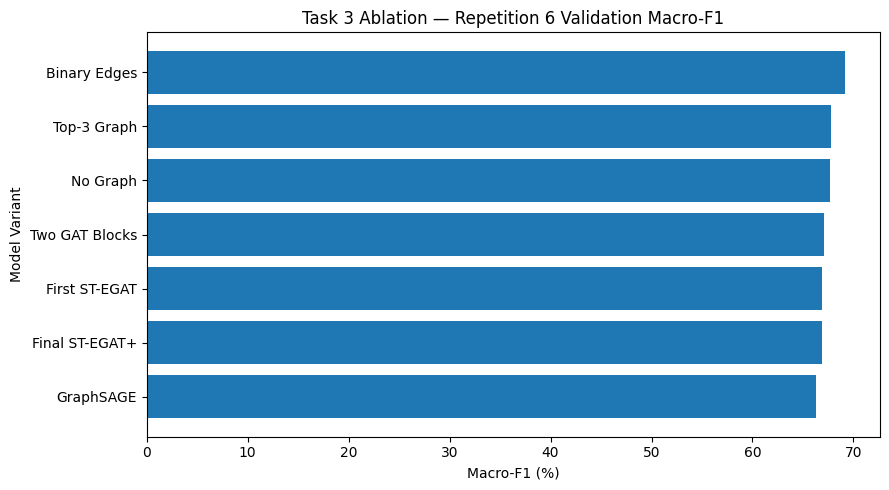

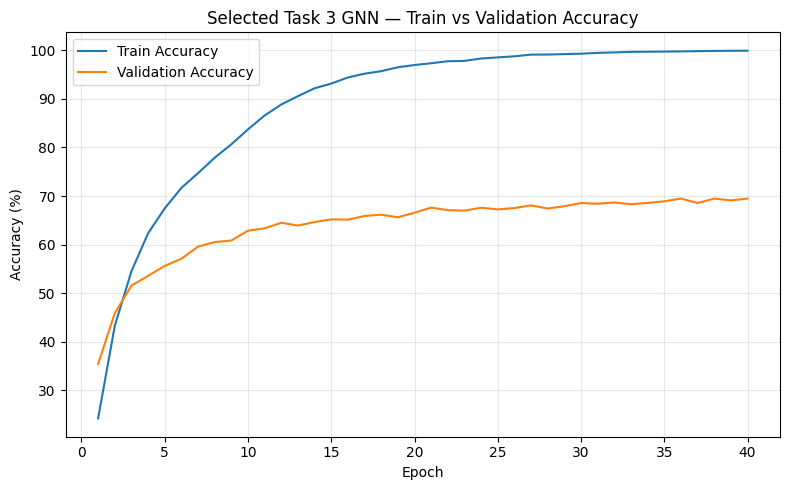

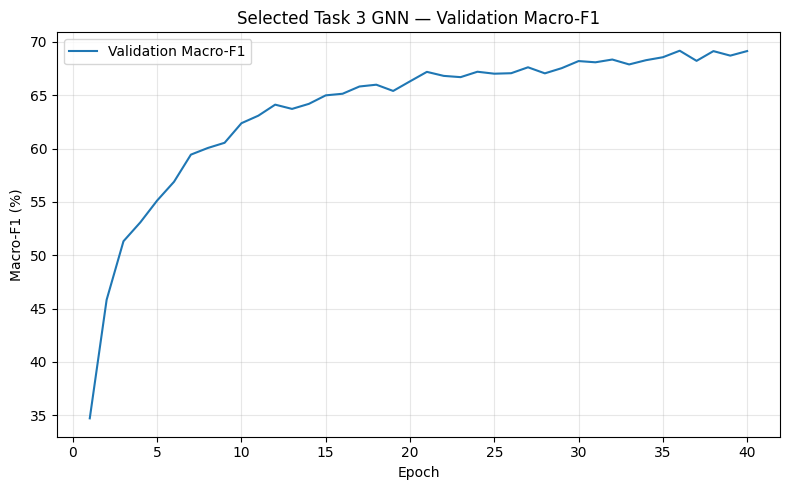

In [12]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

plot_df = ablation_df.sort_values(
    "Macro F1"
)

ax.barh(
    plot_df[
        "Variant"
    ],
    plot_df[
        "Macro F1"
    ] * 100,
)

ax.set_title(
    "Task 3 Ablation — Repetition 6 Validation Macro-F1"
)

ax.set_xlabel(
    "Macro-F1 (%)"
)

ax.set_ylabel(
    "Model Variant"
)

plt.tight_layout()
plt.show()


final_history = ablation_runs[
    selected_gnn_name
][
    "history"
]

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    final_history[
        "Epoch"
    ],
    final_history[
        "Train Accuracy"
    ] * 100,
    label="Train Accuracy",
)

ax.plot(
    final_history[
        "Epoch"
    ],
    final_history[
        "Validation Accuracy"
    ] * 100,
    label="Validation Accuracy",
)

ax.set_title(
    "Selected Task 3 GNN — Train vs Validation Accuracy"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Accuracy (%)"
)

ax.legend()
ax.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    final_history[
        "Epoch"
    ],
    final_history[
        "Validation Macro F1"
    ] * 100,
    label="Validation Macro-F1",
)

ax.set_title(
    "Selected Task 3 GNN — Validation Macro-F1"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Macro-F1 (%)"
)

ax.legend()
ax.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()


## 12. Final Model on the Task 1 and Task 2 Split

In [13]:
final_config = selected_config

final_prep, final_train, final_test = prepare_repetition_split(
    TRAIN_REPETITIONS,
    TEST_REPETITIONS,
)

final_train_edges, final_train_mask = build_graphs_from_frame(
    final_train[
        "frame"
    ],
    top_k=final_config[
        "top_k"
    ],
    mode=final_config[
        "graph_mode"
    ],
)

final_test_edges, final_test_mask = build_graphs_from_frame(
    final_test[
        "frame"
    ],
    top_k=final_config[
        "top_k"
    ],
    mode=final_config[
        "graph_mode"
    ],
)

final_model, final_training_time = train_fixed_epochs(
    final_config,
    final_prep,
    final_train,
    final_train_edges,
    final_train_mask,
    epochs=selected_best_epoch,
)

_, final_test_loader = make_loader(
    final_test,
    final_test_edges,
    final_test_mask,
    final_prep,
    shuffle=False,
)

(
    final_metrics,
    final_true,
    final_pred,
    final_proba,
    final_attention,
) = evaluate_model(
    final_model,
    final_test_loader,
)

final_metrics[
    "Training Time (s)"
] = final_training_time

comparison_rows = []

for name, metrics in [
    (
        "XGBoost Baseline",
        TASK2_XGB_METRICS,
    ),
    (
        "Task 2 First ST-EGAT",
        TASK2_GNN_METRICS,
    ),
    (
        f"Task 3 {selected_gnn_name}",
        final_metrics,
    ),
]:
    row = {
        "Model": name,
    }

    row.update(
        metrics
    )

    comparison_rows.append(
        row
    )

comparison_df = pd.DataFrame(
    comparison_rows
)

display(
    comparison_df.style.format(
        {
            "Accuracy": "{:.2%}",
            "Macro Precision": "{:.2%}",
            "Macro Recall": "{:.2%}",
            "Macro F1": "{:.2%}",
            "Weighted Precision": "{:.2%}",
            "Weighted Recall": "{:.2%}",
            "Weighted F1": "{:.2%}",
            "ROC-AUC Macro": "{:.2%}",
            "PR-AUC Macro": "{:.2%}",
            "Training Time (s)": "{:.1f}",
        }
    )
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,ROC-AUC Macro,PR-AUC Macro,Training Time (s)
0,XGBoost Baseline,77.69%,77.80%,77.19%,77.39%,77.78%,77.69%,77.64%,98.25%,85.99%,308.4
1,Task 2 First ST-EGAT,81.16%,81.09%,80.92%,80.98%,81.17%,81.16%,81.14%,97.66%,86.93%,3495.6
2,Task 3 Binary Edges,80.37%,80.31%,80.14%,80.20%,80.40%,80.37%,80.35%,97.59%,86.38%,2127.9


## 13. Final GNN Full Metric Set

,Gesture,Precision,Recall,F1-score,Support
0,1,0.892,0.905,0.898,"4,722"
1,2,0.799,0.850,0.824,"4,070"
2,3,0.851,0.795,0.822,"3,691"
3,4,0.803,0.787,0.795,"3,522"
4,5,0.742,0.763,0.752,"3,639"
5,6,0.847,0.834,0.841,"2,967"
6,7,0.822,0.853,0.837,"4,519"
7,8,0.755,0.772,0.763,"3,431"
8,9,0.756,0.788,0.772,"3,702"
9,10,0.826,0.781,0.803,"3,809"


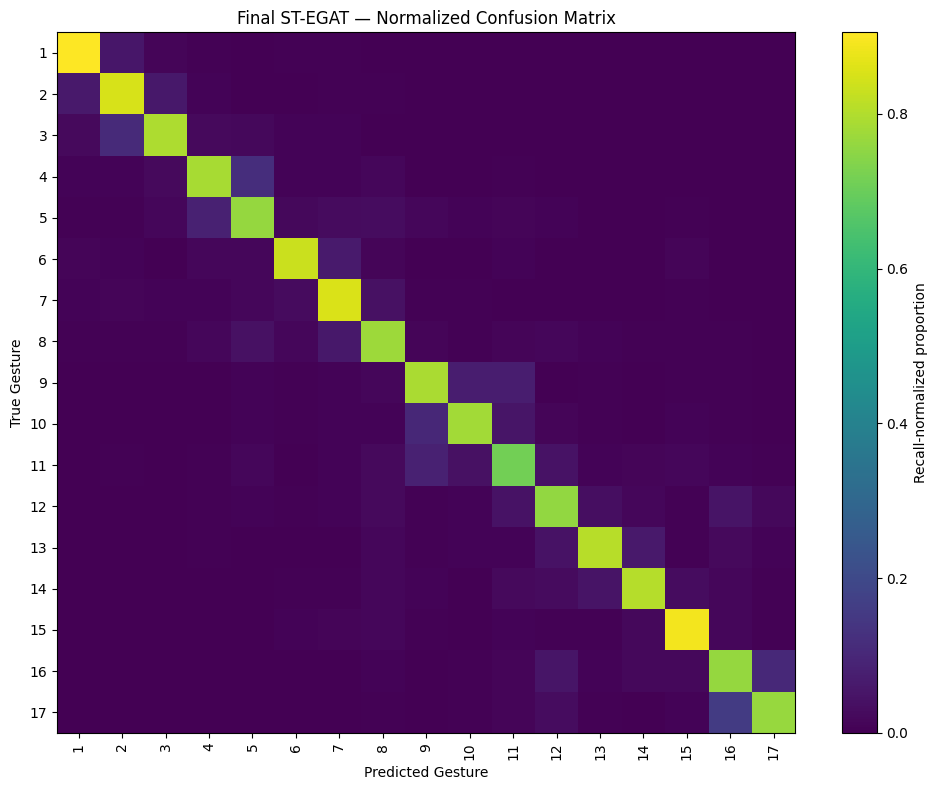

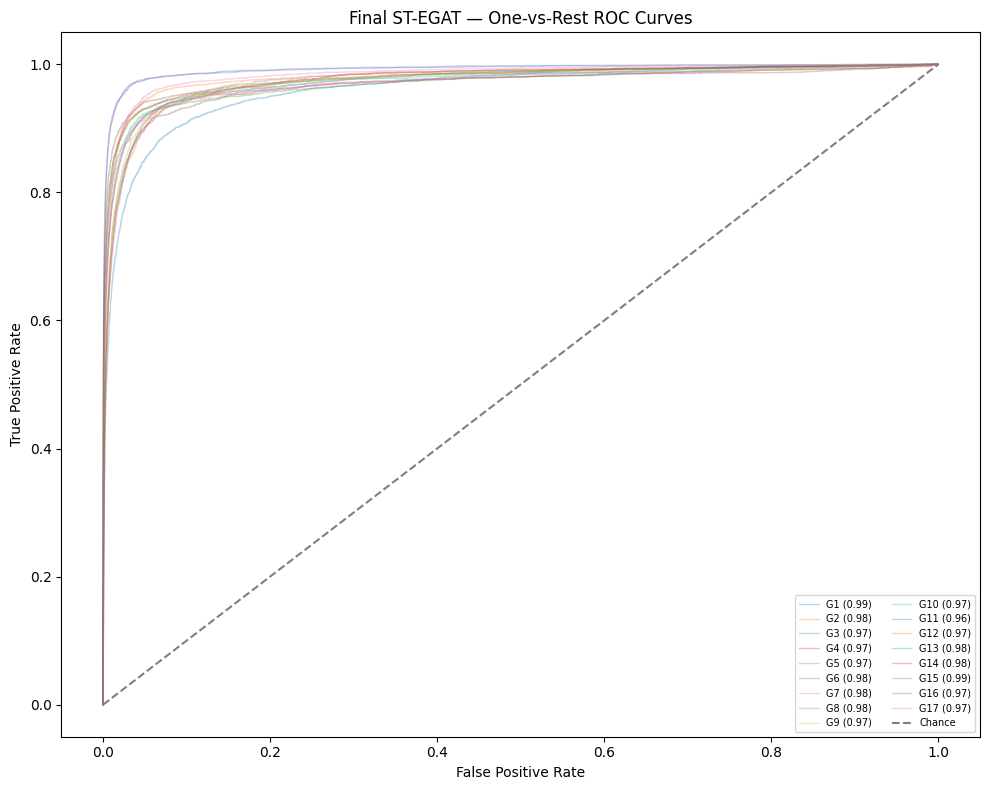

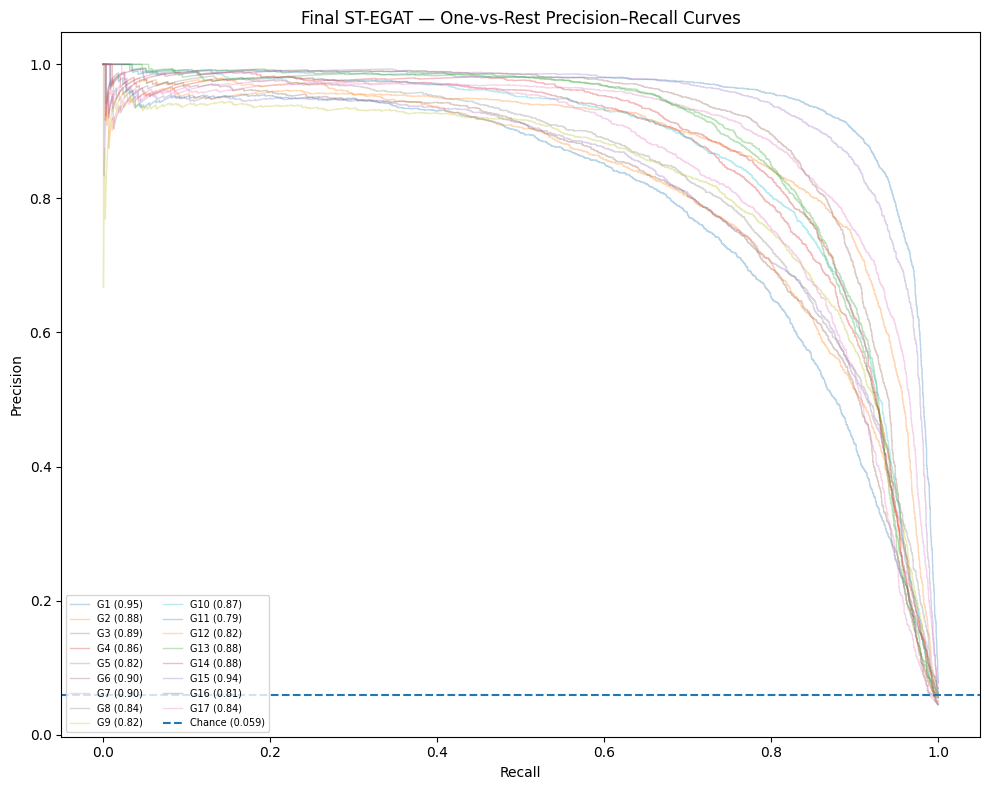

In [14]:
(
    class_precision,
    class_recall,
    class_f1,
    class_support,
) = precision_recall_fscore_support(
    final_true,
    final_pred,
    labels=np.arange(N_CLASSES),
    zero_division=0,
)

per_class_df = pd.DataFrame(
    {
        "Gesture": np.arange(
            1,
            N_CLASSES + 1,
        ),
        "Precision": class_precision,
        "Recall": class_recall,
        "F1-score": class_f1,
        "Support": class_support,
    }
)

display(
    per_class_df.style.format(
        {
            "Precision": "{:.3f}",
            "Recall": "{:.3f}",
            "F1-score": "{:.3f}",
            "Support": "{:,}",
        }
    )
)

cm = confusion_matrix(
    final_true,
    final_pred,
    labels=np.arange(N_CLASSES),
    normalize="true",
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

image = ax.imshow(
    cm,
    aspect="auto",
)

ax.set_title(
    "Final ST-EGAT — Normalized Confusion Matrix"
)

ax.set_xlabel(
    "Predicted Gesture"
)

ax.set_ylabel(
    "True Gesture"
)

ticks = np.arange(
    N_CLASSES
)

ax.set_xticks(
    ticks
)

ax.set_yticks(
    ticks
)

ax.set_xticklabels(
    np.arange(
        1,
        N_CLASSES + 1,
    ),
    rotation=90,
)

ax.set_yticklabels(
    np.arange(
        1,
        N_CLASSES + 1,
    )
)

colorbar = fig.colorbar(
    image,
    ax=ax,
)

colorbar.set_label(
    "Recall-normalized proportion"
)

plt.tight_layout()
plt.show()


final_binary = label_binarize(
    final_true,
    classes=np.arange(N_CLASSES),
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

for class_id in range(
    N_CLASSES
):
    fpr, tpr, _ = roc_curve(
        final_binary[
            :,
            class_id
        ],
        final_proba[
            :,
            class_id
        ],
    )

    class_auc = np.trapz(
        tpr,
        fpr,
    )

    ax.plot(
        fpr,
        tpr,
        alpha=0.30,
        linewidth=1,
        label=(
            f"G{class_id + 1} "
            f"({class_auc:.2f})"
        ),
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Chance",
)

ax.set_title(
    "Final ST-EGAT — One-vs-Rest ROC Curves"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.legend(
    loc="lower right",
    fontsize=7,
    ncol=2,
)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(
    figsize=(10, 8)
)

for class_id in range(
    N_CLASSES
):
    precision, recall, _ = precision_recall_curve(
        final_binary[
            :,
            class_id
        ],
        final_proba[
            :,
            class_id
        ],
    )

    class_ap = average_precision_score(
        final_binary[
            :,
            class_id
        ],
        final_proba[
            :,
            class_id
        ],
    )

    ax.plot(
        recall,
        precision,
        alpha=0.30,
        linewidth=1,
        label=(
            f"G{class_id + 1} "
            f"({class_ap:.2f})"
        ),
    )

chance_level = (
    1.0
    / N_CLASSES
)

ax.axhline(
    chance_level,
    linestyle="--",
    label=(
        f"Chance ({chance_level:.3f})"
    ),
)

ax.set_title(
    "Final ST-EGAT — One-vs-Rest Precision–Recall Curves"
)

ax.set_xlabel(
    "Recall"
)

ax.set_ylabel(
    "Precision"
)

ax.legend(
    loc="lower left",
    fontsize=7,
    ncol=2,
)

plt.tight_layout()
plt.show()

## 14. Five-Fold Grouped Cross-Validation and Significance Test

In [15]:
cv_indices = repetition_indices(
    TRAIN_REPETITIONS
)

cv_frame = all_df.iloc[
    cv_indices
].reset_index(
    drop=True
)

cv_labels = (
    cv_frame[
        "gesture_label"
    ].to_numpy(
        dtype=np.int64
    )
    - 1
)

cv_groups = (
    cv_frame[
        "subject_id"
    ].to_numpy(
        dtype=np.int64
    )
    * 10
    + cv_frame[
        "repetition_id"
    ].to_numpy(
        dtype=np.int64
    )
)

cv_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cv_rows = []

for fold_id, (
    train_positions,
    test_positions,
) in enumerate(
    cv_splitter.split(
        np.zeros(
            len(
                cv_indices
            )
        ),
        cv_labels,
        groups=cv_groups,
    ),
    start=1,
):
    fold_train_indices = cv_indices[
        train_positions
    ]

    fold_test_indices = cv_indices[
        test_positions
    ]

    fold_train_groups = set(
        cv_groups[
            train_positions
        ].tolist()
    )

    fold_test_groups = set(
        cv_groups[
            test_positions
        ].tolist()
    )

    assert fold_train_groups.isdisjoint(
        fold_test_groups
    )

    fold_prep = fit_preprocessor(
        fold_train_indices
    )

    fold_train = transform_indices(
        fold_train_indices,
        fold_prep,
    )

    fold_test = transform_indices(
        fold_test_indices,
        fold_prep,
    )

    print(
        f"\nFold {fold_id} | "
        f"train windows={len(fold_train['y']):,} | "
        f"test windows={len(fold_test['y']):,} | "
        f"held-out subject-repetition groups={len(fold_test_groups)}"
    )

    fold_train_edges, fold_train_mask = build_graphs_from_frame(
        fold_train[
            "frame"
        ],
        top_k=final_config[
            "top_k"
        ],
        mode=final_config[
            "graph_mode"
        ],
    )

    fold_test_edges, fold_test_mask = build_graphs_from_frame(
        fold_test[
            "frame"
        ],
        top_k=final_config[
            "top_k"
        ],
        mode=final_config[
            "graph_mode"
        ],
    )

    fold_model, fold_gnn_time = train_fixed_epochs(
        final_config,
        fold_prep,
        fold_train,
        fold_train_edges,
        fold_train_mask,
        epochs=selected_best_epoch,
    )

    _, fold_test_loader = make_loader(
        fold_test,
        fold_test_edges,
        fold_test_mask,
        fold_prep,
        shuffle=False,
    )

    fold_gnn_metrics, _, _, _, _ = evaluate_model(
        fold_model,
        fold_test_loader,
    )

    fold_xgb_weights = np.asarray(
        [
            fold_prep[
                "class_weights"
            ][
                label
            ]
            for label
            in fold_train[
                "y"
            ]
        ],
        dtype=np.float32,
    )

    fold_xgb = XGBClassifier(
        objective="multi:softprob",
        num_class=N_CLASSES,
        n_estimators=700,
        max_depth=10,
        learning_rate=0.05,
        min_child_weight=1,
        subsample=0.90,
        colsample_bytree=0.90,
        gamma=0.0,
        reg_alpha=0.0,
        reg_lambda=1.0,
        tree_method="hist",
        device=(
            "cuda"
            if torch.cuda.is_available()
            else "cpu"
        ),
        eval_metric="mlogloss",
        random_state=RANDOM_STATE + fold_id,
    )

    xgb_start = time.perf_counter()

    fold_xgb.fit(
        fold_train[
            "global"
        ],
        fold_train[
            "y"
        ],
        sample_weight=fold_xgb_weights,
        verbose=False,
    )

    fold_xgb_time = (
        time.perf_counter()
        - xgb_start
    )

    fold_xgb_proba = fold_xgb.predict_proba(
        fold_test[
            "global"
        ]
    )

    fold_xgb_pred = np.argmax(
        fold_xgb_proba,
        axis=1,
    )

    fold_xgb_true = fold_test[
        "y"
    ]

    fold_xgb_binary = label_binarize(
        fold_xgb_true,
        classes=np.arange(N_CLASSES),
    )

    fold_xgb_metrics = {
        "Accuracy": accuracy_score(
            fold_xgb_true,
            fold_xgb_pred,
        ),
        "Macro Precision": precision_score(
            fold_xgb_true,
            fold_xgb_pred,
            average="macro",
            zero_division=0,
        ),
        "Macro Recall": recall_score(
            fold_xgb_true,
            fold_xgb_pred,
            average="macro",
            zero_division=0,
        ),
        "Macro F1": f1_score(
            fold_xgb_true,
            fold_xgb_pred,
            average="macro",
            zero_division=0,
        ),
        "Weighted Precision": precision_score(
            fold_xgb_true,
            fold_xgb_pred,
            average="weighted",
            zero_division=0,
        ),
        "Weighted Recall": recall_score(
            fold_xgb_true,
            fold_xgb_pred,
            average="weighted",
            zero_division=0,
        ),
        "Weighted F1": f1_score(
            fold_xgb_true,
            fold_xgb_pred,
            average="weighted",
            zero_division=0,
        ),
        "ROC-AUC Macro": roc_auc_score(
            fold_xgb_binary,
            fold_xgb_proba,
            average="macro",
            multi_class="ovr",
        ),
        "PR-AUC Macro": average_precision_score(
            fold_xgb_binary,
            fold_xgb_proba,
            average="macro",
        ),
    }

    row = {
        "Fold": fold_id,
        "Held-Out Groups": len(
            fold_test_groups
        ),
        "XGBoost Time (s)": fold_xgb_time,
        "Final GNN Time (s)": fold_gnn_time,
    }

    for metric_name in [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "ROC-AUC Macro",
        "PR-AUC Macro",
    ]:
        row[
            f"XGBoost {metric_name}"
        ] = fold_xgb_metrics[
            metric_name
        ]

        row[
            f"Final GNN {metric_name}"
        ] = fold_gnn_metrics[
            metric_name
        ]

    cv_rows.append(
        row
    )

    del fold_model
    del fold_xgb
    del fold_train_edges
    del fold_train_mask
    del fold_test_edges
    del fold_test_mask
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


cv_df = pd.DataFrame(
    cv_rows
)

display_columns = [
    "Fold",
    "Held-Out Groups",
    "XGBoost Accuracy",
    "Final GNN Accuracy",
    "XGBoost Macro F1",
    "Final GNN Macro F1",
    "XGBoost ROC-AUC Macro",
    "Final GNN ROC-AUC Macro",
    "XGBoost PR-AUC Macro",
    "Final GNN PR-AUC Macro",
]

display(
    cv_df[
        display_columns
    ].style.format(
        {
            "XGBoost Accuracy": "{:.2%}",
            "Final GNN Accuracy": "{:.2%}",
            "XGBoost Macro F1": "{:.2%}",
            "Final GNN Macro F1": "{:.2%}",
            "XGBoost ROC-AUC Macro": "{:.2%}",
            "Final GNN ROC-AUC Macro": "{:.2%}",
            "XGBoost PR-AUC Macro": "{:.2%}",
            "Final GNN PR-AUC Macro": "{:.2%}",
        }
    )
)

metric_names = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted Precision",
    "Weighted Recall",
    "Weighted F1",
    "ROC-AUC Macro",
    "PR-AUC Macro",
]

summary_rows = []

for model_name, prefix in [
    (
        "XGBoost",
        "XGBoost",
    ),
    (
        f"Task 3 {selected_gnn_name}",
        "Final GNN",
    ),
]:
    row = {
        "Model": model_name,
    }

    for metric_name in metric_names:
        values = cv_df[
            f"{prefix} {metric_name}"
        ]

        row[
            f"{metric_name} Mean"
        ] = values.mean()

        row[
            f"{metric_name} Std"
        ] = values.std(
            ddof=1
        )

    summary_rows.append(
        row
    )

cv_summary_df = pd.DataFrame(
    summary_rows
)

summary_format = {}

for metric_name in metric_names:
    summary_format[
        f"{metric_name} Mean"
    ] = "{:.2%}"

    summary_format[
        f"{metric_name} Std"
    ] = "{:.2%}"

display(
    cv_summary_df.style.format(
        summary_format
    )
)

gnn_fold_f1 = cv_df[
    "Final GNN Macro F1"
].to_numpy()

xgb_fold_f1 = cv_df[
    "XGBoost Macro F1"
].to_numpy()

try:
    wilcoxon_result = wilcoxon(
        gnn_fold_f1,
        xgb_fold_f1,
        alternative="greater",
        zero_method="wilcox",
    )

    wilcoxon_statistic = float(
        wilcoxon_result.statistic
    )

    wilcoxon_p_value = float(
        wilcoxon_result.pvalue
    )
except ValueError:
    wilcoxon_statistic = np.nan
    wilcoxon_p_value = 1.0

print(
    "Wilcoxon signed-rank statistic:",
    wilcoxon_statistic,
)

print(
    "One-sided p-value:",
    wilcoxon_p_value,
)

print(
    "Significant at alpha=0.05:",
    wilcoxon_p_value < 0.05,
)

cv_df.to_csv(
    OUTPUT_ROOT
    / "Group06_NinaProDB2_task3_cv_results.csv",
    index=False,
)

cv_summary_df.to_csv(
    OUTPUT_ROOT
    / "Group06_NinaProDB2_task3_cv_summary.csv",
    index=False,
)



Fold 1 | train windows=96,955 | test windows=24,218 | held-out subject-repetition groups=33

Fold 2 | train windows=96,709 | test windows=24,464 | held-out subject-repetition groups=32

Fold 3 | train windows=95,890 | test windows=25,283 | held-out subject-repetition groups=32

Fold 4 | train windows=97,803 | test windows=23,370 | held-out subject-repetition groups=31

Fold 5 | train windows=97,335 | test windows=23,838 | held-out subject-repetition groups=32


,Fold,Held-Out Groups,XGBoost Accuracy,Final GNN Accuracy,XGBoost Macro F1,Final GNN Macro F1,XGBoost ROC-AUC Macro,Final GNN ROC-AUC Macro,XGBoost PR-AUC Macro,Final GNN PR-AUC Macro
0,1,33,67.81%,68.97%,67.56%,68.72%,96.04%,94.00%,74.09%,72.63%
1,2,32,63.74%,66.12%,63.48%,65.96%,95.00%,92.84%,69.86%,69.28%
2,3,32,62.85%,65.23%,62.49%,65.07%,94.97%,92.82%,69.43%,68.34%
3,4,31,65.66%,67.38%,65.37%,67.12%,95.31%,93.40%,72.36%,70.83%
4,5,32,66.90%,68.90%,66.58%,68.79%,95.88%,94.31%,73.84%,72.97%


,Model,Accuracy Mean,Accuracy Std,Macro Precision Mean,Macro Precision Std,Macro Recall Mean,Macro Recall Std,Macro F1 Mean,Macro F1 Std,Weighted Precision Mean,Weighted Precision Std,Weighted Recall Mean,Weighted Recall Std,Weighted F1 Mean,Weighted F1 Std,ROC-AUC Macro Mean,ROC-AUC Macro Std,PR-AUC Macro Mean,PR-AUC Macro Std
0,XGBoost,65.39%,2.08%,65.64%,1.90%,64.92%,2.19%,65.10%,2.11%,65.59%,2.00%,65.39%,2.08%,65.32%,2.10%,95.44%,0.50%,71.92%,2.18%
1,Task 3 Binary Edges,67.32%,1.66%,67.36%,1.49%,67.07%,1.77%,67.13%,1.65%,67.49%,1.58%,67.32%,1.66%,67.33%,1.64%,93.47%,0.67%,70.81%,2.02%


Wilcoxon signed-rank statistic: 15.0
One-sided p-value: 0.03125
Significant at alpha=0.05: True


## 16. Save Final Model

In [16]:
model_path = MODEL_ROOT / "Group06_NinaProDB2_best.pth"

torch.save(
    {
        "model_state_dict": final_model.state_dict(),
        "model_config": final_config,
        "selected_variant": selected_gnn_name,
        "best_epoch": selected_best_epoch,
        "train_repetitions": TRAIN_REPETITIONS,
        "test_repetitions": TEST_REPETITIONS,
        "subjects": SUBJECTS,
        "window_size": WINDOW_SIZE,
        "step_size": STEP_SIZE,
        "n_classes": N_CLASSES,
        "n_channels": N_CHANNELS,
        "selected_feature_names": final_prep[
            "selected_feature_names"
        ],
    },
    model_path,
)

label_map = {
    str(index): int(
        index + 1
    )
    for index
    in range(N_CLASSES)
}

label_map_path = MODEL_ROOT / "Group06_NinaProDB2_label_map.json"

with open(
    label_map_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        label_map,
        file,
        indent=2,
    )

print("Saved model    :", model_path)
print("Saved label map:", label_map_path)
print("Selected model :", selected_gnn_name)
print("Final epoch    :", selected_best_epoch)
print("Final train reps:", TRAIN_REPETITIONS)
print("Final test reps :", TEST_REPETITIONS)


Saved model    : /kaggle/working/models/Group06_NinaProDB2_best.pth
Saved label map: /kaggle/working/models/Group06_NinaProDB2_label_map.json
Selected model : Binary Edges
Final epoch    : 36
Final train reps: [1, 3, 4, 6]
Final test reps : [2, 5]


## 17. Task 3 Improvement Findings

In [17]:
final_cv_row = cv_summary_df.loc[
    cv_summary_df[
        "Model"
    ]
    != "XGBoost"
].iloc[
    0
]

xgb_cv_row = cv_summary_df.loc[
    cv_summary_df[
        "Model"
    ]
    == "XGBoost"
].iloc[
    0
]

print("Task 3 Final Summary")
print("--------------------")

print(
    "Selected final GNN           :",
    selected_gnn_name,
)

print(
    "Final test Accuracy          :",
    f"{final_metrics['Accuracy'] * 100:.2f}%"
)

print(
    "Final test Macro-F1          :",
    f"{final_metrics['Macro F1'] * 100:.2f}%"
)

print(
    "Task 2 first GNN Macro-F1    :",
    f"{TASK2_GNN_METRICS['Macro F1'] * 100:.2f}%"
)

print(
    "Task 2 XGBoost Macro-F1      :",
    f"{TASK2_XGB_METRICS['Macro F1'] * 100:.2f}%"
)

print(
    "5-fold GNN Macro-F1          :",
    f"{final_cv_row['Macro F1 Mean'] * 100:.2f}% ± "
    f"{final_cv_row['Macro F1 Std'] * 100:.2f}%"
)

print(
    "5-fold XGBoost Macro-F1      :",
    f"{xgb_cv_row['Macro F1 Mean'] * 100:.2f}% ± "
    f"{xgb_cv_row['Macro F1 Std'] * 100:.2f}%"
)

print(
    "Wilcoxon statistic           :",
    wilcoxon_statistic,
)

print(
    "Wilcoxon p-value             :",
    f"{wilcoxon_p_value:.6f}"
)

print(
    "Graph vs no-graph Macro-F1   :",
    f"{graph_gain:+.2f} percentage points"
)

print(
    "Saved final checkpoint       :",
    model_path.name,
)

Task 3 Final Summary
--------------------
Selected final GNN           : Binary Edges
Final test Accuracy          : 80.37%
Final test Macro-F1          : 80.20%
Task 2 first GNN Macro-F1    : 80.98%
Task 2 XGBoost Macro-F1      : 77.39%
5-fold GNN Macro-F1          : 67.13% ± 1.65%
5-fold XGBoost Macro-F1      : 65.10% ± 2.11%
Wilcoxon statistic           : 15.0
Wilcoxon p-value             : 0.031250
Graph vs no-graph Macro-F1   : +1.52 percentage points
Saved final checkpoint       : Group06_NinaProDB2_best.pth
